# Project Setup

## Import Libraries

In [1]:
# Data handling
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.neighbors import NearestNeighbors
import umap

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Cluster label matching
from scipy.optimize import linear_sum_assignment

# Deep learning / VAE
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Utilities
import random
import warnings

warnings.filterwarnings("ignore")

print("=" * 55)
print("ENVIRONMENT SETUP")
print("=" * 55)
print("Python libraries imported successfully.")
print("=" * 55)

ENVIRONMENT SETUP
Python libraries imported successfully.


## Configure Reproducibility and Visualization

In [2]:
# Set a fixed random seed for reproducibility
RANDOM_SEED = 1606

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Set seed for GPU if available
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Configure plotting style
sns.set_theme(style="whitegrid", context="notebook")

# Configure default figure properties
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Display configuration summary
print("=" * 55)
print("REPRODUCIBILITY AND VISUALIZATION SETTINGS")
print("=" * 55)
print(f"{'Random Seed':<30}: {RANDOM_SEED}")
print(f"{'CUDA Available':<30}: {torch.cuda.is_available()}")
print(f"{'Plotting Style':<30}: Whitegrid")
print(f"{'Default Figure Size':<30}: {plt.rcParams['figure.figsize']}")
print("=" * 55)

REPRODUCIBILITY AND VISUALIZATION SETTINGS
Random Seed                   : 1606
CUDA Available                : True
Plotting Style                : Whitegrid
Default Figure Size           : [12.0, 8.0]


## Define Project Paths

In [3]:
# Current notebook directory
NOTEBOOK_DIR = Path.cwd()

# Project root directory
ROOT_FOLDER = NOTEBOOK_DIR.parent

# Define project directories
DATA_DIR = ROOT_FOLDER / "results" / "1.dataset_creation"
RESULTS_DIR = ROOT_FOLDER / "results" / "2.embedding_clustering"
PLOTS_DIR = ROOT_FOLDER / "plots" / "2.embedding_clustering"

# Create output directories if they do not exist
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Display directory configuration
print("=" * 55)
print("PROJECT DIRECTORY CONFIGURATION")
print("=" * 55)
print(f"{'Project Root':<16}: {ROOT_FOLDER}")
print(f"{'Input Data':<16}: {DATA_DIR}")
print(f"{'Results Output':<16}: {RESULTS_DIR}")
print(f"{'Plots Output':<16}: {PLOTS_DIR}")
print("=" * 55)

PROJECT DIRECTORY CONFIGURATION
Project Root    : C:\Users\samsa\Documents\ICU Clustering
Input Data      : C:\Users\samsa\Documents\ICU Clustering\results\1.dataset_creation
Results Output  : C:\Users\samsa\Documents\ICU Clustering\results\2.embedding_clustering
Plots Output    : C:\Users\samsa\Documents\ICU Clustering\plots\2.embedding_clustering


# Data Loading and Preparation

## Load Scaled Dataset and Feature Metadata

In [4]:
# Load the scaled clustering dataset
scaled_df = pd.read_csv(
    DATA_DIR / "clustering_dataset_scaled.csv"
)

# Load clustering feature metadata
feature_names_df = pd.read_csv(
    DATA_DIR / "clustering_feature_names.csv"
)

# Display loading summary
print("=" * 55)
print("DATA LOADING SUMMARY")
print("=" * 55)
print(f"{'Patients Loaded':<30}: {scaled_df.shape[0]:,}")
print(f"{'Dataset Columns':<30}: {scaled_df.shape[1]}")
print(f"{'Clustering Features':<30}: {feature_names_df.shape[0]}")
print(f"{'Dataset Shape':<30}: {scaled_df.shape}")
print(f"{'Feature Metadata Shape':<30}: {feature_names_df.shape}")
print("=" * 55)

DATA LOADING SUMMARY
Patients Loaded               : 7,859
Dataset Columns               : 81
Clustering Features           : 80
Dataset Shape                 : (7859, 81)
Feature Metadata Shape        : (80, 1)


## Inspect Dataset Structure and Feature Set

In [5]:
# Extract clustering feature names
feature_names = feature_names_df.iloc[:, 0].to_list()

# Define identifier column
ID_COLUMN = "patientunitstayid"

# Check whether the identifier column exists
id_present = ID_COLUMN in scaled_df.columns

# Identify any clustering features missing from the dataset
missing_features = [
    feature
    for feature in feature_names
    if feature not in scaled_df.columns
]

# Display validation summary
print("=" * 55)
print("DATASET STRUCTURE AND FEATURE VALIDATION")
print("=" * 55)
print(f"{'Total Dataset Columns':<30}: {scaled_df.shape[1]}")
print(f"{'Clustering Features':<30}: {len(feature_names)}")
print(f"{'Identifier Column':<30}: {ID_COLUMN}")
print(f"{'Identifier Present':<30}: {id_present}")
print(f"{'Missing Features':<30}: {len(missing_features)}")
print("-" * 55)

if id_present and len(missing_features) == 0:
    print("VALIDATION STATUS: PASSED")
    print("All clustering features are present in the dataset.")
else:
    print("VALIDATION STATUS: FAILED")

    if not id_present:
        print(f"Missing identifier column: {ID_COLUMN}")

    if missing_features:
        print(f"Missing clustering features: {missing_features}")

print("=" * 55)

DATASET STRUCTURE AND FEATURE VALIDATION
Total Dataset Columns         : 81
Clustering Features           : 80
Identifier Column             : patientunitstayid
Identifier Present            : True
Missing Features              : 0
-------------------------------------------------------
VALIDATION STATUS: PASSED
All clustering features are present in the dataset.


## Construct the Clustering Feature Matrix

In [6]:
# Store patient identifiers separately
patient_ids = scaled_df[ID_COLUMN].copy()

# Construct the clustering feature matrix
X = scaled_df[feature_names].copy()

# Display feature matrix summary
print("=" * 55)
print("CLUSTERING FEATURE MATRIX SUMMARY")
print("=" * 55)
print(f"{'Number of Patients':<30}: {X.shape[0]:,}")
print(f"{'Number of Features':<30}: {X.shape[1]}")
print(f"{'Patient IDs Stored':<30}: {len(patient_ids):,}")
print(f"{'Feature Matrix Shape':<30}: {X.shape}")
print("=" * 55)

CLUSTERING FEATURE MATRIX SUMMARY
Number of Patients            : 7,859
Number of Features            : 80
Patient IDs Stored            : 7,859
Feature Matrix Shape          : (7859, 80)


## Validate Feature Matrix Integrity

In [7]:
# Count missing values
missing_values = X.isna().sum().sum()

# Count infinite values
infinite_values = np.isinf(X.to_numpy()).sum()

# Determine validation status
matrix_valid = (missing_values == 0) and (infinite_values == 0)

# Display validation summary
print("=" * 55)
print("FEATURE MATRIX INTEGRITY CHECK")
print("=" * 55)
print(f"{'Missing Values':<30}: {missing_values:,}")
print(f"{'Infinite Values':<30}: {infinite_values:,}")
print(f"{'Validation Status':<30}: {'PASSED' if matrix_valid else 'FAILED'}")
print("-" * 55)

if matrix_valid:
    print("Feature matrix is ready for dimensionality reduction.")
else:
    print("Feature matrix requires cleaning before further analysis.")

print("=" * 55)

FEATURE MATRIX INTEGRITY CHECK
Missing Values                : 0
Infinite Values               : 0
Validation Status             : PASSED
-------------------------------------------------------
Feature matrix is ready for dimensionality reduction.


# Dimensionality Reduction

## PCA Embedding

### Fit PCA Representation

In [8]:
# Apply PCA while retaining at least 95% of total variance
pca = PCA(
    n_components=0.95,
    svd_solver="full"
)

# Fit PCA and transform the feature matrix
pca_embedding = pca.fit_transform(X)

# Reconstruct the original feature matrix
X_reconstructed = pca.inverse_transform(pca_embedding)

# Calculate reconstruction error
reconstruction_error = np.mean(
    (X.to_numpy() - X_reconstructed) ** 2
)

# Calculate total explained variance
total_explained_variance = pca.explained_variance_ratio_.sum()

# Display PCA summary
print("=" * 55)
print("PCA REPRESENTATION SUMMARY")
print("=" * 55)
print(f"{'Original Features':<30}: {X.shape[1]}")
print(f"{'PCA Components Retained':<30}: {pca.n_components_}")
print(
    f"{'Explained Variance':<30}: "
    f"{total_explained_variance * 100:.2f}%"
)
print(f"{'Reconstruction Error':<30}: {reconstruction_error:.6f}")
print(f"{'PCA Embedding Shape':<30}: {pca_embedding.shape}")
print("=" * 55)

PCA REPRESENTATION SUMMARY
Original Features             : 80
PCA Components Retained       : 25
Explained Variance            : 95.45%
Reconstruction Error          : 0.000894
PCA Embedding Shape           : (7859, 25)


### Evaluate PCA Explained Variance

In [9]:
# Store explained variance for each retained principal component
pca_variance_df = pd.DataFrame({
    "Component": [
        f"PC{i + 1}"
        for i in range(pca.n_components_)
    ],
    "Explained_Variance_Ratio": pca.explained_variance_ratio_,
    "Cumulative_Explained_Variance": np.cumsum(
        pca.explained_variance_ratio_
    )
})

# Save explained variance results
pca_variance_df.to_csv(
    RESULTS_DIR / "01.pca_explained_variance.csv",
    index=False
)

# Create a formatted summary for display
pca_variance_summary = pca_variance_df.copy()

pca_variance_summary["Explained Variance (%)"] = (
    pca_variance_summary["Explained_Variance_Ratio"] * 100
)

pca_variance_summary["Cumulative Variance (%)"] = (
    pca_variance_summary["Cumulative_Explained_Variance"] * 100
)

# Display first 10 principal components
print("=" * 65)
print("PCA EXPLAINED VARIANCE SUMMARY")
print("=" * 65)

print(
    pca_variance_summary[
        [
            "Component",
            "Explained Variance (%)",
            "Cumulative Variance (%)"
        ]
    ]
    .head(25)
    .to_string(
        index=False,
        formatters={
            "Explained Variance (%)": "{:.2f}".format,
            "Cumulative Variance (%)": "{:.2f}".format
        }
    )
)

print("-" * 65)
print(
    f"{'Total Components Retained':<35}: "
    f"{pca.n_components_}"
)
print(
    f"{'Total Variance Retained':<35}: "
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)
print("=" * 65)

PCA EXPLAINED VARIANCE SUMMARY
Component Explained Variance (%) Cumulative Variance (%)
      PC1                  17.40                   17.40
      PC2                  16.05                   33.45
      PC3                  13.23                   46.68
      PC4                   6.03                   52.71
      PC5                   5.19                   57.90
      PC6                   4.66                   62.56
      PC7                   3.95                   66.51
      PC8                   3.47                   69.97
      PC9                   3.00                   72.97
     PC10                   2.79                   75.76
     PC11                   2.70                   78.46
     PC12                   2.25                   80.71
     PC13                   2.19                   82.90
     PC14                   1.75                   84.65
     PC15                   1.57                   86.22
     PC16                   1.55                   87.76


### Visualize PCA Representation

PCA VISUALIZATION SUMMARY
PC1 Explained Variance             : 17.40%
PC2 Explained Variance             : 16.05%
Variance Shown in 2D Plot          : 33.45%
Full PCA Representation            : (7859, 25)
------------------------------------------------------------
Note: The plot uses PC1 and PC2 only.
      The full 25-dimensional PCA embedding is preserved.


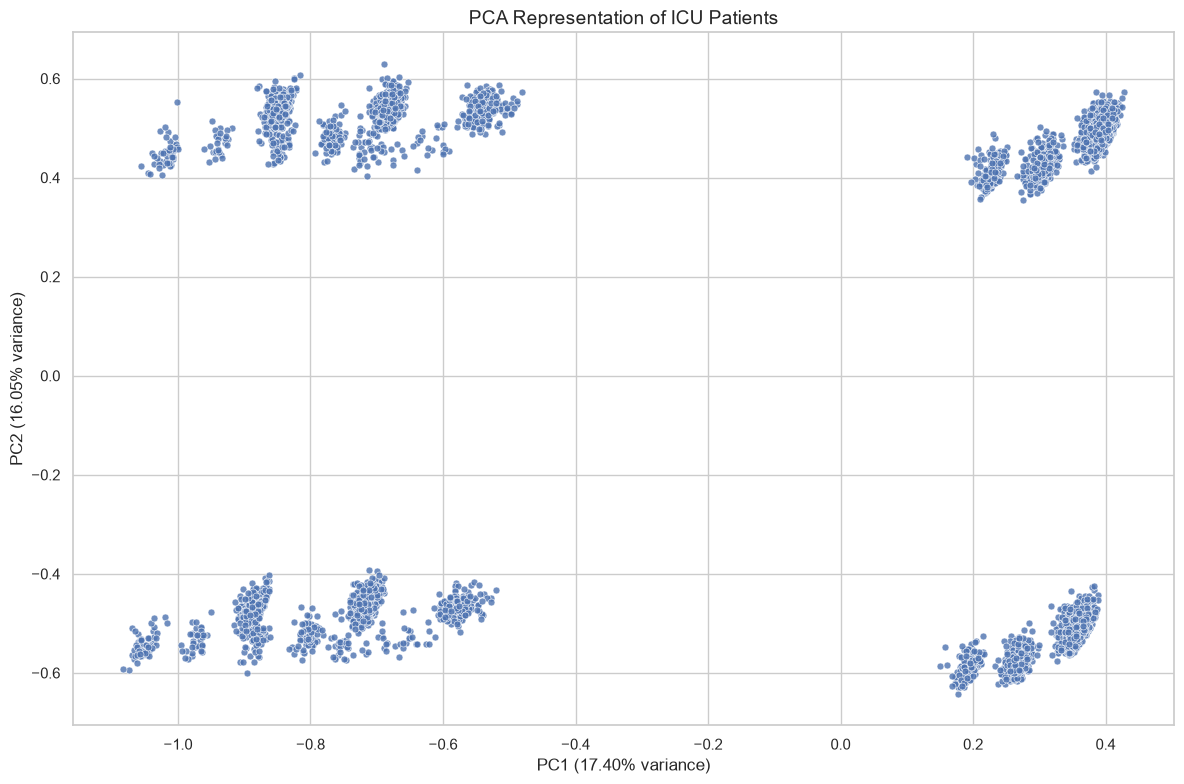

In [10]:
# Create a 2D DataFrame for PCA visualization
pca_df = pd.DataFrame({
    "patientunitstayid": patient_ids.to_numpy(),
    "PC1": pca_embedding[:, 0],
    "PC2": pca_embedding[:, 1]
})

# Save the 2D PCA visualization coordinates
pca_df.to_csv(
    RESULTS_DIR / "02.pca_embedding.csv",
    index=False
)

# Calculate variance represented by the first two components
pc1_variance = pca.explained_variance_ratio_[0] * 100
pc2_variance = pca.explained_variance_ratio_[1] * 100
two_dimensional_variance = pc1_variance + pc2_variance

# Display visualization summary
print("=" * 60)
print("PCA VISUALIZATION SUMMARY")
print("=" * 60)
print(f"{'PC1 Explained Variance':<35}: {pc1_variance:.2f}%")
print(f"{'PC2 Explained Variance':<35}: {pc2_variance:.2f}%")
print(
    f"{'Variance Shown in 2D Plot':<35}: "
    f"{two_dimensional_variance:.2f}%"
)
print(
    f"{'Full PCA Representation':<35}: "
    f"{pca_embedding.shape}"
)
print("-" * 60)
print("Note: The plot uses PC1 and PC2 only.")
print("      The full 25-dimensional PCA embedding is preserved.")
print("=" * 60)

# Create the 2D PCA scatter plot
plt.figure(figsize=(12, 8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=25,
    edgecolors="white",
    linewidths=0.5,
    alpha=0.8
)

# Label axes with explained variance
plt.xlabel(f"PC1 ({pc1_variance:.2f}% variance)")
plt.ylabel(f"PC2 ({pc2_variance:.2f}% variance)")

plt.title("PCA Representation of ICU Patients")

plt.tight_layout()

# Save plot
plt.savefig(
    PLOTS_DIR / "01.pca_embedding.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## t-SNE Embedding

### Tune Perplexity using Neighborhood Preservation

In [11]:
# Define candidate perplexity values
perplexity_values = [
    10, 20, 30, 40, 50,
    60, 70, 80, 90, 100
]

# Store t-SNE embeddings and evaluation results
tsne_embeddings = {}
tsne_tuning_results = []

print("=" * 75)
print("t-SNE PERPLEXITY TUNING")
print("=" * 75)

# Evaluate each candidate perplexity
for perplexity in perplexity_values:

    # Initialize t-SNE
    tsne_model = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        max_iter=1000,
        random_state=RANDOM_SEED
    )

    # Generate 2D t-SNE embedding
    embedding = tsne_model.fit_transform(X)

    # Store embedding for later use
    tsne_embeddings[perplexity] = embedding

    # Measure preservation of original local neighborhoods
    trust_score = trustworthiness(
        X,
        embedding,
        n_neighbors=30
    )

    # Measure preservation of embedded neighborhoods
    continuity_score = trustworthiness(
        embedding,
        X,
        n_neighbors=30
    )

    # Combined neighborhood-preservation score
    quality_score = (
        trust_score + continuity_score
    ) / 2

    # Store evaluation results
    tsne_tuning_results.append({
        "Perplexity": perplexity,
        "Trustworthiness": trust_score,
        "Continuity": continuity_score,
        "Quality_Score": quality_score
    })

# Convert results to DataFrame
tsne_tuning_df = pd.DataFrame(
    tsne_tuning_results
)

# Rank configurations by overall embedding quality
tsne_tuning_df = (
    tsne_tuning_df
    .sort_values(
        "Quality_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

# Select best perplexity
best_tsne_perplexity = int(
    tsne_tuning_df.loc[0, "Perplexity"]
)

# Save tuning results
tsne_tuning_df.to_csv(
    RESULTS_DIR / "03.tsne_embedding_quality.csv",
    index=False
)

# Create formatted display table
tsne_display_df = tsne_tuning_df.copy()

for column in [
    "Trustworthiness",
    "Continuity",
    "Quality_Score"
]:
    tsne_display_df[column] = (
        tsne_display_df[column]
        .map(lambda value: f"{value:.4f}")
    )

# Display results
print(
    tsne_display_df.to_string(index=False)
)

print("-" * 75)
print(
    f"{'Selected Perplexity':<35}: "
    f"{best_tsne_perplexity}"
)
print(
    f"{'Best Trustworthiness':<35}: "
    f"{tsne_tuning_df.loc[0, 'Trustworthiness']:.4f}"
)
print(
    f"{'Best Continuity':<35}: "
    f"{tsne_tuning_df.loc[0, 'Continuity']:.4f}"
)
print(
    f"{'Best Quality Score':<35}: "
    f"{tsne_tuning_df.loc[0, 'Quality_Score']:.4f}"
)
print("=" * 75)

t-SNE PERPLEXITY TUNING
 Perplexity Trustworthiness Continuity Quality_Score
         80          0.9794     0.9774        0.9784
         70          0.9795     0.9768        0.9781
         90          0.9792     0.9770        0.9781
         60          0.9795     0.9766        0.9781
        100          0.9790     0.9765        0.9778
         50          0.9790     0.9759        0.9775
         40          0.9793     0.9753        0.9773
         30          0.9786     0.9742        0.9764
         20          0.9772     0.9728        0.9750
         10          0.9725     0.9695        0.9710
---------------------------------------------------------------------------
Selected Perplexity                : 80
Best Trustworthiness               : 0.9794
Best Continuity                    : 0.9774
Best Quality Score                 : 0.9784


### Generate Final t-SNE Representation

In [12]:
# Retrieve the t-SNE embedding for the selected perplexity
tsne_embedding = tsne_embeddings[best_tsne_perplexity]

# Store t-SNE coordinates with patient identifiers
tsne_df = pd.DataFrame({
    "patientunitstayid": patient_ids.to_numpy(),
    "tsne_1": tsne_embedding[:, 0],
    "tsne_2": tsne_embedding[:, 1]
})

# Save the final t-SNE representation
tsne_df.to_csv(
    RESULTS_DIR / "05.tsne_embedding.csv",
    index=False
)

# Display final t-SNE summary
print("=" * 60)
print("FINAL t-SNE REPRESENTATION SUMMARY")
print("=" * 60)
print(f"{'Selected Perplexity':<35}: {best_tsne_perplexity}")
print(f"{'Number of Patients':<35}: {tsne_embedding.shape[0]:,}")
print(f"{'Embedding Dimensions':<35}: {tsne_embedding.shape[1]}")
print(f"{'t-SNE Embedding Shape':<35}: {tsne_embedding.shape}")
print("=" * 60)

FINAL t-SNE REPRESENTATION SUMMARY
Selected Perplexity                : 80
Number of Patients                 : 7,859
Embedding Dimensions               : 2
t-SNE Embedding Shape              : (7859, 2)


### Visualize t-SNE Representation

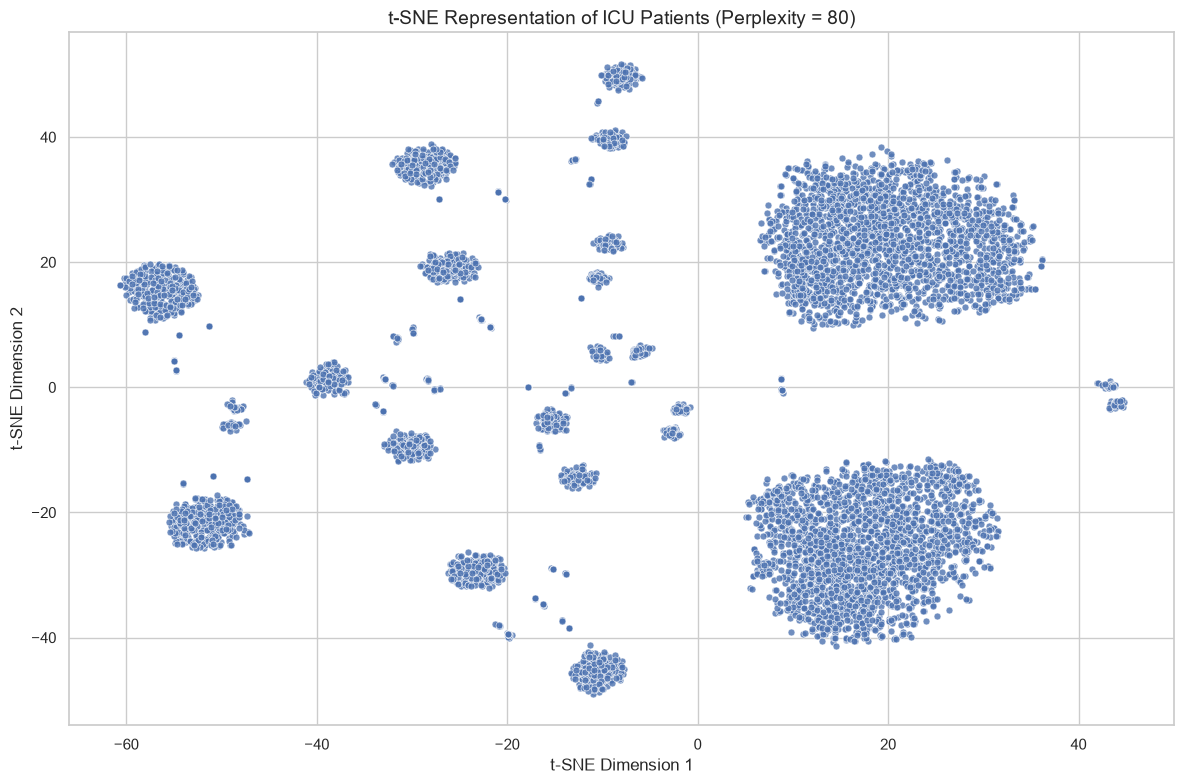

In [13]:
# Create the final 2D t-SNE scatter plot
plt.figure(figsize=(12, 8))

plt.scatter(
    tsne_df["tsne_1"],
    tsne_df["tsne_2"],
    s=25,
    edgecolors="white",
    linewidths=0.5,
    alpha=0.8
)

# Add axis labels and title
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.title(
    f"t-SNE Representation of ICU Patients "
    f"(Perplexity = {best_tsne_perplexity})"
)

plt.tight_layout()

# Save plot
plt.savefig(
    PLOTS_DIR / "02.tsne_embedding.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## UMAP Embedding

### Tune UMAP Hyperparameters Using Neighborhood Preservation

In [14]:
# Define candidate UMAP hyperparameters
n_neighbors_values = [5, 10, 20, 40, 50, 75, 100]
min_dist_values = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

# Store UMAP embeddings and evaluation results
umap_embeddings = {}
umap_tuning_results = []

total_runs = len(n_neighbors_values) * len(min_dist_values)
current_run = 0

print("=" * 100)
print("UMAP HYPERPARAMETER TUNING")
print("=" * 100)

for n_neighbors in n_neighbors_values:
    for min_dist in min_dist_values:

        current_run += 1

        # Initialize UMAP
        umap_model = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric="euclidean",
            random_state=RANDOM_SEED,
            n_jobs=1
        )

        # Generate embedding
        embedding = umap_model.fit_transform(X)

        # Store embedding
        umap_embeddings[
            (n_neighbors, min_dist)
        ] = embedding

        # Calculate trustworthiness
        trust_score = trustworthiness(
            X,
            embedding,
            n_neighbors=30
        )

        # Calculate continuity
        continuity_score = trustworthiness(
            embedding,
            X,
            n_neighbors=30
        )

        # Calculate overall quality score
        quality_score = (
            trust_score + continuity_score
        ) / 2

        # Store results
        umap_tuning_results.append({
            "n_neighbors": n_neighbors,
            "min_dist": min_dist,
            "Trustworthiness": trust_score,
            "Continuity": continuity_score,
            "Quality_Score": quality_score
        })

        # Display progress line by line
        print(
            f"[{current_run:02d}/{total_runs}] "
            f"n_neighbors={n_neighbors:<3} | "
            f"min_dist={min_dist:<4} | "
            f"Trustworthiness={trust_score:.4f} | "
            f"Continuity={continuity_score:.4f} | "
            f"Quality={quality_score:.4f}",
            flush=True
        )

# Convert results to DataFrame
umap_tuning_df = pd.DataFrame(umap_tuning_results)

# Rank configurations
umap_tuning_df = (
    umap_tuning_df
    .sort_values(
        "Quality_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

# Select best parameters
best_umap_neighbors = int(
    umap_tuning_df.loc[0, "n_neighbors"]
)

best_umap_min_dist = float(
    umap_tuning_df.loc[0, "min_dist"]
)

# Save results
umap_tuning_df.to_csv(
    RESULTS_DIR / "06.umap_embedding_quality.csv",
    index=False
)

print("=" * 100)
print("BEST UMAP CONFIGURATION")
print("=" * 100)
print(f"{'Selected n_neighbors':<35}: {best_umap_neighbors}")
print(f"{'Selected min_dist':<35}: {best_umap_min_dist}")
print(
    f"{'Best Trustworthiness':<35}: "
    f"{umap_tuning_df.loc[0, 'Trustworthiness']:.4f}"
)
print(
    f"{'Best Continuity':<35}: "
    f"{umap_tuning_df.loc[0, 'Continuity']:.4f}"
)
print(
    f"{'Best Quality Score':<35}: "
    f"{umap_tuning_df.loc[0, 'Quality_Score']:.4f}"
)
print("=" * 100)

UMAP HYPERPARAMETER TUNING
[01/42] n_neighbors=5   | min_dist=0.05 | Trustworthiness=0.9578 | Continuity=0.9682 | Quality=0.9630
[02/42] n_neighbors=5   | min_dist=0.1  | Trustworthiness=0.9573 | Continuity=0.9669 | Quality=0.9621
[03/42] n_neighbors=5   | min_dist=0.2  | Trustworthiness=0.9556 | Continuity=0.9672 | Quality=0.9614
[04/42] n_neighbors=5   | min_dist=0.3  | Trustworthiness=0.9536 | Continuity=0.9659 | Quality=0.9598
[05/42] n_neighbors=5   | min_dist=0.4  | Trustworthiness=0.9516 | Continuity=0.9674 | Quality=0.9595
[06/42] n_neighbors=5   | min_dist=0.5  | Trustworthiness=0.9510 | Continuity=0.9690 | Quality=0.9600
[07/42] n_neighbors=10  | min_dist=0.05 | Trustworthiness=0.9573 | Continuity=0.9713 | Quality=0.9643
[08/42] n_neighbors=10  | min_dist=0.1  | Trustworthiness=0.9561 | Continuity=0.9731 | Quality=0.9646
[09/42] n_neighbors=10  | min_dist=0.2  | Trustworthiness=0.9538 | Continuity=0.9724 | Quality=0.9631
[10/42] n_neighbors=10  | min_dist=0.3  | Trustworthine

### Generate Final UMAP Representation

In [15]:
# Create the final UMAP model using selected hyperparameters
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=best_umap_neighbors,
    min_dist=best_umap_min_dist,
    metric="euclidean",
    random_state=RANDOM_SEED,
    n_jobs=1
)

# Generate the final UMAP representation
umap_embedding = umap_model.fit_transform(X)

# Store UMAP coordinates with patient identifiers
umap_df = pd.DataFrame({
    "patientunitstayid": patient_ids.to_numpy(),
    "umap_1": umap_embedding[:, 0],
    "umap_2": umap_embedding[:, 1]
})

# Save the final UMAP representation
umap_df.to_csv(
    RESULTS_DIR / "08.umap_embedding.csv",
    index=False
)

# Display final UMAP summary
print("=" * 60)
print("FINAL UMAP REPRESENTATION SUMMARY")
print("=" * 60)
print(
    f"{'Selected n_neighbors':<35}: "
    f"{best_umap_neighbors}"
)
print(
    f"{'Selected min_dist':<35}: "
    f"{best_umap_min_dist}"
)
print(
    f"{'Distance Metric':<35}: "
    f"euclidean"
)
print(
    f"{'Number of Patients':<35}: "
    f"{umap_embedding.shape[0]:,}"
)
print(
    f"{'Embedding Dimensions':<35}: "
    f"{umap_embedding.shape[1]}"
)
print(
    f"{'UMAP Embedding Shape':<35}: "
    f"{umap_embedding.shape}"
)
print("=" * 60)

FINAL UMAP REPRESENTATION SUMMARY
Selected n_neighbors               : 40
Selected min_dist                  : 0.05
Distance Metric                    : euclidean
Number of Patients                 : 7,859
Embedding Dimensions               : 2
UMAP Embedding Shape               : (7859, 2)


### Visualize UMAP Representation

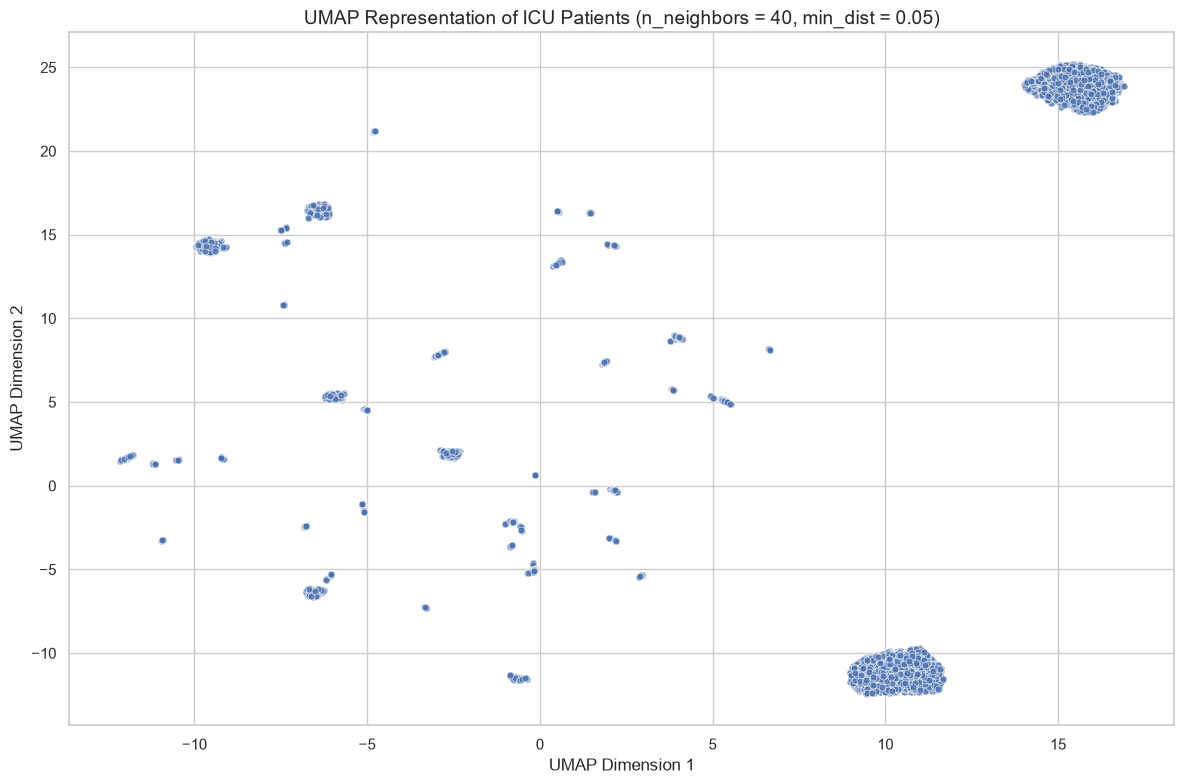

In [16]:
# Create the final 2D UMAP scatter plot
plt.figure(figsize=(12, 8))

plt.scatter(
    umap_df["umap_1"],
    umap_df["umap_2"],
    s=25,
    edgecolors="white",
    linewidths=0.5,
    alpha=0.8
)

# Add axis labels and title
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.title(
    f"UMAP Representation of ICU Patients "
    f"(n_neighbors = {best_umap_neighbors}, "
    f"min_dist = {best_umap_min_dist})"
)

plt.tight_layout()

# Save plot
plt.savefig(
    PLOTS_DIR / "03.umap_embedding.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Variational Autoencoder (VAE) Embedding

### Define VAE Architecture

In [17]:
# Select computation device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# Define the Variational Autoencoder
class VAE(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim1,
        hidden_dim2,
        latent_dim=2
    ):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU()
        )

        # Latent distribution parameters
        self.mu_layer = nn.Linear(
            hidden_dim2,
            latent_dim
        )

        self.logvar_layer = nn.Linear(
            hidden_dim2,
            latent_dim
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, input_dim)
        )

    # Encode input into latent distribution
    def encode(self, x):

        encoded = self.encoder(x)

        mu = self.mu_layer(encoded)
        logvar = self.logvar_layer(encoded)

        return mu, logvar

    # Sample from the latent distribution
    def reparameterize(self, mu, logvar):

        std = torch.exp(
            0.5 * logvar
        )

        epsilon = torch.randn_like(std)

        return mu + epsilon * std

    # Decode latent representation
    def decode(self, z):

        return self.decoder(z)

    # Complete forward pass
    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        reconstructed = self.decode(z)

        return reconstructed, mu, logvar


# Display architecture setup summary
print("=" * 60)
print("VAE ARCHITECTURE SETUP")
print("=" * 60)
print(f"{'Computation Device':<35}: {device}")
print(f"{'Input Features':<35}: {X.shape[1]}")
print(f"{'Latent Dimensions':<35}: 2")
print(f"{'Architecture Status':<35}: Defined Successfully")
print("=" * 60)

VAE ARCHITECTURE SETUP
Computation Device                 : cuda
Input Features                     : 80
Latent Dimensions                  : 2
Architecture Status                : Defined Successfully


### Prepare Dataset for VAE Training

In [18]:
# Convert the feature matrix into a PyTorch tensor
X_tensor = torch.tensor(
    X.to_numpy(),
    dtype=torch.float32
)

# Create dataset for VAE training
vae_dataset = TensorDataset(X_tensor)

# Display dataset preparation summary
print("=" * 60)
print("VAE DATASET PREPARATION SUMMARY")
print("=" * 60)
print(f"{'Number of Patients':<35}: {len(vae_dataset):,}")
print(f"{'Number of Features':<35}: {X_tensor.shape[1]}")
print(f"{'Tensor Data Type':<35}: {X_tensor.dtype}")
print(f"{'VAE Dataset Shape':<35}: {tuple(X_tensor.shape)}")
print("=" * 60)

VAE DATASET PREPARATION SUMMARY
Number of Patients                 : 7,859
Number of Features                 : 80
Tensor Data Type                   : torch.float32
VAE Dataset Shape                  : (7859, 80)


### Define VAE Loss Function

In [19]:
# Define the VAE loss function
def vae_loss(
    reconstructed,
    original,
    mu,
    logvar,
    beta
):

    # Reconstruction loss
    reconstruction_loss = nn.functional.mse_loss(
        reconstructed,
        original,
        reduction="mean"
    )

    # KL-divergence loss
    kl_loss = -0.5 * torch.mean(
        1
        + logvar
        - mu.pow(2)
        - logvar.exp()
    )

    # Total VAE loss
    total_loss = (
        reconstruction_loss
        + beta * kl_loss
    )

    return (
        total_loss,
        reconstruction_loss,
        kl_loss
    )


# Display loss function setup summary
print("=" * 60)
print("VAE LOSS FUNCTION SETUP")
print("=" * 60)
print(f"{'Reconstruction Loss':<35}: Mean Squared Error")
print(f"{'Latent Regularization':<35}: KL Divergence")
print(f"{'Beta Weighting':<35}: Enabled")
print(f"{'Loss Function Status':<35}: Defined Successfully")
print("=" * 60)

VAE LOSS FUNCTION SETUP
Reconstruction Loss                : Mean Squared Error
Latent Regularization              : KL Divergence
Beta Weighting                     : Enabled
Loss Function Status               : Defined Successfully


### Define VAE Training Procedure

In [20]:
# Define a reusable function for training one VAE model
def train_vae(
    hidden_dim1,
    hidden_dim2,
    learning_rate,
    beta,
    batch_size=128,
    epochs=50
):

    # Reset random seeds for reproducible training
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)

    # Create DataLoader
    train_loader = DataLoader(
        vae_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Initialize VAE model
    model = VAE(
        input_dim=X_tensor.shape[1],
        hidden_dim1=hidden_dim1,
        hidden_dim2=hidden_dim2,
        latent_dim=2
    ).to(device)

    # Initialize Adam optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    # Store average loss for each epoch
    epoch_losses = []

    # Train the VAE
    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for batch in train_loader:

            # Move batch to selected device
            batch_data = batch[0].to(device)

            # Reset gradients
            optimizer.zero_grad()

            # Forward pass
            reconstructed, mu, logvar = model(
                batch_data
            )

            # Calculate VAE loss
            loss, _, _ = vae_loss(
                reconstructed,
                batch_data,
                mu,
                logvar,
                beta
            )

            # Backpropagation
            loss.backward()

            # Update model parameters
            optimizer.step()

            # Accumulate batch loss
            total_loss += loss.item()

        # Calculate average epoch loss
        average_loss = (
            total_loss / len(train_loader)
        )

        epoch_losses.append(
            average_loss
        )

    return model, epoch_losses


# Display training function setup summary
print("=" * 60)
print("VAE TRAINING PROCEDURE SETUP")
print("=" * 60)
print(f"{'Optimizer':<35}: Adam")
print(f"{'Default Batch Size':<35}: 128")
print(f"{'Default Epochs':<35}: 50")
print(f"{'Latent Dimensions':<35}: 2")
print(f"{'Reproducible Training':<35}: Enabled")
print(f"{'Training Function Status':<35}: Defined Successfully")
print("=" * 60)

VAE TRAINING PROCEDURE SETUP
Optimizer                          : Adam
Default Batch Size                 : 128
Default Epochs                     : 50
Latent Dimensions                  : 2
Reproducible Training              : Enabled
Training Function Status           : Defined Successfully


### Define VAE Latent Representation Extraction

In [21]:
# Define a function to extract the 2D VAE latent representation
def get_vae_embedding(model):

    # Switch model to evaluation mode
    model.eval()

    # Disable gradient computation
    with torch.no_grad():

        # Move the complete feature matrix to the selected device
        data = X_tensor.to(device)

        # Extract latent mean
        mu, _ = model.encode(data)

        # Convert latent representation to NumPy
        embedding = mu.cpu().numpy()

    return embedding


# Display latent extraction setup summary
print("=" * 60)
print("VAE LATENT REPRESENTATION SETUP")
print("=" * 60)
print(f"{'Representation Used':<35}: Latent Mean (mu)")
print(f"{'Latent Dimensions':<35}: 2")
print(f"{'Gradient Computation':<35}: Disabled")
print(f"{'Extraction Function Status':<35}: Defined Successfully")
print("=" * 60)

VAE LATENT REPRESENTATION SETUP
Representation Used                : Latent Mean (mu)
Latent Dimensions                  : 2
Gradient Computation               : Disabled
Extraction Function Status         : Defined Successfully


### Define VAE Hyperparameter Search Space

In [22]:
# Define candidate encoder architectures
vae_hidden_configs = [
    (64, 32),
    (128, 64),
    (256, 128)
]

# Define candidate learning rates
vae_learning_rates = [
    0.001,
    0.0007,
    0.0005
]

# Define candidate beta values
vae_beta_values = [
    0.01,
    0.1,
    0.5,
    1.0
]

# Keep these settings fixed during hyperparameter tuning
vae_batch_size = 128
vae_epochs = 100
vae_latent_dim = 2

# Calculate total number of configurations
total_vae_configs = (
    len(vae_hidden_configs)
    * len(vae_learning_rates)
    * len(vae_beta_values)
)

# Display search space summary
print("=" * 70)
print("VAE HYPERPARAMETER SEARCH SPACE")
print("=" * 70)
print(f"{'Hidden Layer Configurations':<35}: {vae_hidden_configs}")
print(f"{'Learning Rates':<35}: {vae_learning_rates}")
print(f"{'Beta Values':<35}: {vae_beta_values}")
print(f"{'Batch Size':<35}: {vae_batch_size}")
print(f"{'Training Epochs':<35}: {vae_epochs}")
print(f"{'Latent Dimensions':<35}: {vae_latent_dim}")
print(f"{'Total VAE Configurations':<35}: {total_vae_configs}")
print("=" * 70)

VAE HYPERPARAMETER SEARCH SPACE
Hidden Layer Configurations        : [(64, 32), (128, 64), (256, 128)]
Learning Rates                     : [0.001, 0.0007, 0.0005]
Beta Values                        : [0.01, 0.1, 0.5, 1.0]
Batch Size                         : 128
Training Epochs                    : 100
Latent Dimensions                  : 2
Total VAE Configurations           : 36


### Tune VAE Hyperparameters Using Neighborhood Preservation

In [23]:
# Store results and embeddings from every VAE configuration
vae_tuning_results = []
vae_embeddings = {}

configuration_number = 0

print("=" * 110)
print("VAE HYPERPARAMETER TUNING")
print("=" * 110)

# Evaluate every VAE hyperparameter combination
for hidden_dim1, hidden_dim2 in vae_hidden_configs:

    for learning_rate in vae_learning_rates:

        for beta in vae_beta_values:

            configuration_number += 1

            # Train the VAE
            model, epoch_losses = train_vae(
                hidden_dim1=hidden_dim1,
                hidden_dim2=hidden_dim2,
                learning_rate=learning_rate,
                beta=beta,
                batch_size=vae_batch_size,
                epochs=vae_epochs
            )

            # Extract the 2D latent representation
            embedding = get_vae_embedding(model)

            # Store embedding
            vae_embeddings[
                (
                    hidden_dim1,
                    hidden_dim2,
                    learning_rate,
                    beta
                )
            ] = embedding

            # Calculate trustworthiness
            trust_score = trustworthiness(
                X,
                embedding,
                n_neighbors=30
            )

            # Calculate continuity
            continuity_score = trustworthiness(
                embedding,
                X,
                n_neighbors=30
            )

            # Calculate reconstruction error
            model.eval()

            with torch.no_grad():

                data = X_tensor.to(device)

                mu, _ = model.encode(data)
                reconstructed = model.decode(mu)

                reconstruction_mse = (
                    nn.functional.mse_loss(
                        reconstructed,
                        data,
                        reduction="mean"
                    ).item()
                )

            # Store results
            vae_tuning_results.append({
                "Hidden_Dim1": hidden_dim1,
                "Hidden_Dim2": hidden_dim2,
                "Learning_Rate": learning_rate,
                "Beta": beta,
                "Final_Training_Loss": epoch_losses[-1],
                "Trustworthiness": trust_score,
                "Continuity": continuity_score,
                "Reconstruction_MSE": reconstruction_mse
            })

            # Display progress
            print(
                f"[{configuration_number:02d}/{total_vae_configs}] "
                f"Hidden=({hidden_dim1:>3}, {hidden_dim2:>3}) | "
                f"LR={learning_rate:<6} | "
                f"Beta={beta:<4} | "
                f"Trust={trust_score:.4f} | "
                f"Continuity={continuity_score:.4f} | "
                f"Recon MSE={reconstruction_mse:.6f} | "
                f"Loss={epoch_losses[-1]:.6f}",
                flush=True
            )

# Convert results to DataFrame
vae_tuning_df = pd.DataFrame(
    vae_tuning_results
)

# Save tuning results
vae_tuning_df.to_csv(
    RESULTS_DIR / "09.vae_tuning_results.csv",
    index=False
)

print("=" * 110)
print("VAE HYPERPARAMETER SEARCH COMPLETED")
print("=" * 110)
print(
    f"{'Configurations Evaluated':<35}: "
    f"{len(vae_tuning_df)}"
)
print("=" * 110)

VAE HYPERPARAMETER TUNING
[01/36] Hidden=( 64,  32) | LR=0.001  | Beta=0.01 | Trust=0.9045 | Continuity=0.9487 | Recon MSE=0.015492 | Loss=0.019345
[02/36] Hidden=( 64,  32) | LR=0.001  | Beta=0.1  | Trust=0.7197 | Continuity=0.8612 | Recon MSE=0.019705 | Loss=0.019707
[03/36] Hidden=( 64,  32) | LR=0.001  | Beta=0.5  | Trust=0.6746 | Continuity=0.8092 | Recon MSE=0.019705 | Loss=0.019708
[04/36] Hidden=( 64,  32) | LR=0.001  | Beta=1.0  | Trust=0.6673 | Continuity=0.8120 | Recon MSE=0.019705 | Loss=0.019708
[05/36] Hidden=( 64,  32) | LR=0.0007 | Beta=0.01 | Trust=0.8756 | Continuity=0.9462 | Recon MSE=0.015017 | Loss=0.019287
[06/36] Hidden=( 64,  32) | LR=0.0007 | Beta=0.1  | Trust=0.7576 | Continuity=0.8803 | Recon MSE=0.019699 | Loss=0.019705
[07/36] Hidden=( 64,  32) | LR=0.0007 | Beta=0.5  | Trust=0.6620 | Continuity=0.8120 | Recon MSE=0.019698 | Loss=0.019706
[08/36] Hidden=( 64,  32) | LR=0.0007 | Beta=1.0  | Trust=0.6265 | Continuity=0.7669 | Recon MSE=0.019700 | Loss=0.01970

### Select Best VAE Configuration

In [24]:
# Rank VAE embedding quality metrics
vae_tuning_df["Trust_Rank"] = (
    vae_tuning_df["Trustworthiness"]
    .rank(ascending=False)
)

vae_tuning_df["Continuity_Rank"] = (
    vae_tuning_df["Continuity"]
    .rank(ascending=False)
)

vae_tuning_df["Reconstruction_Rank"] = (
    vae_tuning_df["Reconstruction_MSE"]
    .rank(ascending=True)
)

# Calculate combined rank
vae_tuning_df["Total_Rank"] = (
    vae_tuning_df["Trust_Rank"]
    + vae_tuning_df["Continuity_Rank"]
    + vae_tuning_df["Reconstruction_Rank"]
)

# Sort configurations from best to worst
vae_tuning_df = (
    vae_tuning_df
    .sort_values("Total_Rank")
    .reset_index(drop=True)
)

# Select best VAE hyperparameters
best_hidden_dim1 = int(
    vae_tuning_df.loc[0, "Hidden_Dim1"]
)

best_hidden_dim2 = int(
    vae_tuning_df.loc[0, "Hidden_Dim2"]
)

best_learning_rate = float(
    vae_tuning_df.loc[0, "Learning_Rate"]
)

best_beta = float(
    vae_tuning_df.loc[0, "Beta"]
)

# Retrieve selected VAE embedding
best_vae_embedding = vae_embeddings[
    (
        best_hidden_dim1,
        best_hidden_dim2,
        best_learning_rate,
        best_beta
    )
]

# Save ranked tuning results
vae_tuning_df.to_csv(
    RESULTS_DIR / "09.vae_tuning_results.csv",
    index=False
)

# Display selection summary
print("=" * 70)
print("BEST VAE CONFIGURATION")
print("=" * 70)

print(
    f"{'Hidden Layers':<35}: "
    f"({best_hidden_dim1}, {best_hidden_dim2})"
)

print(
    f"{'Learning Rate':<35}: "
    f"{best_learning_rate}"
)

print(
    f"{'Beta':<35}: "
    f"{best_beta}"
)

print(
    f"{'Trustworthiness':<35}: "
    f"{vae_tuning_df.loc[0, 'Trustworthiness']:.4f}"
)

print(
    f"{'Continuity':<35}: "
    f"{vae_tuning_df.loc[0, 'Continuity']:.4f}"
)

print(
    f"{'Reconstruction MSE':<35}: "
    f"{vae_tuning_df.loc[0, 'Reconstruction_MSE']:.6f}"
)

print(
    f"{'Total Rank':<35}: "
    f"{vae_tuning_df.loc[0, 'Total_Rank']:.0f}"
)

print("=" * 70)

# Display ranked configurations
display(vae_tuning_df)

BEST VAE CONFIGURATION
Hidden Layers                      : (256, 128)
Learning Rate                      : 0.0005
Beta                               : 0.01
Trustworthiness                    : 0.9203
Continuity                         : 0.9618
Reconstruction MSE                 : 0.012454
Total Rank                         : 3


,Hidden_Dim1,Hidden_Dim2,Learning_Rate,Beta,Final_Training_Loss,Trustworthiness,Continuity,Reconstruction_MSE,Trust_Rank,Continuity_Rank,Reconstruction_Rank,Total_Rank
0,256,128,0.0005,0.01,0.019322,0.920346,0.961824,0.012454,1.0,1.0,1.0,3.0
1,256,128,0.0010,0.01,0.019437,0.920281,0.958293,0.014414,2.0,3.0,5.0,10.0
2,64,32,0.0005,0.01,0.019270,0.909648,0.955335,0.014368,3.0,4.0,3.0,10.0
3,128,64,0.0010,0.01,0.019399,0.903743,0.959490,0.014401,5.0,2.0,4.0,11.0
4,64,32,0.0010,0.01,0.019345,0.904452,0.948679,0.015492,4.0,6.0,9.0,19.0
5,128,64,0.0005,0.01,0.019416,0.901684,0.948225,0.014508,6.0,7.0,6.0,19.0
6,256,128,0.0007,0.01,0.019439,0.868467,0.930502,0.014161,9.0,9.0,2.0,20.0
7,128,64,0.0007,0.01,0.019324,0.897788,0.950761,0.015465,7.0,5.0,8.0,20.0
8,64,32,0.0007,0.01,0.019287,0.875611,0.946181,0.015017,8.0,8.0,7.0,23.0
9,128,64,0.0007,0.10,0.019752,0.722723,0.887667,0.019697,13.0,12.0,13.0,38.0


### Generate Final VAE Representation

In [25]:
# Use the selected VAE embedding
vae_embedding = best_vae_embedding

# Create final VAE DataFrame
vae_df = pd.DataFrame({
    "patientunitstayid": patient_ids.to_numpy(),
    "vae_1": vae_embedding[:, 0],
    "vae_2": vae_embedding[:, 1]
})

# Save the final VAE representation
vae_df.to_csv(
    RESULTS_DIR / "11.vae_embedding.csv",
    index=False
)

# Display final VAE representation summary
print("=" * 70)
print("FINAL VAE REPRESENTATION SUMMARY")
print("=" * 70)

print(
    f"{'Selected Hidden Layers':<35}: "
    f"({best_hidden_dim1}, {best_hidden_dim2})"
)

print(
    f"{'Selected Learning Rate':<35}: "
    f"{best_learning_rate}"
)

print(
    f"{'Selected Beta':<35}: "
    f"{best_beta}"
)

print(
    f"{'Number of Patients':<35}: "
    f"{vae_embedding.shape[0]:,}"
)

print(
    f"{'Embedding Dimensions':<35}: "
    f"{vae_embedding.shape[1]}"
)

print(
    f"{'VAE Embedding Shape':<35}: "
    f"{vae_embedding.shape}"
)

print("=" * 70)

FINAL VAE REPRESENTATION SUMMARY
Selected Hidden Layers             : (256, 128)
Selected Learning Rate             : 0.0005
Selected Beta                      : 0.01
Number of Patients                 : 7,859
Embedding Dimensions               : 2
VAE Embedding Shape                : (7859, 2)


### Visualize VAE Representation

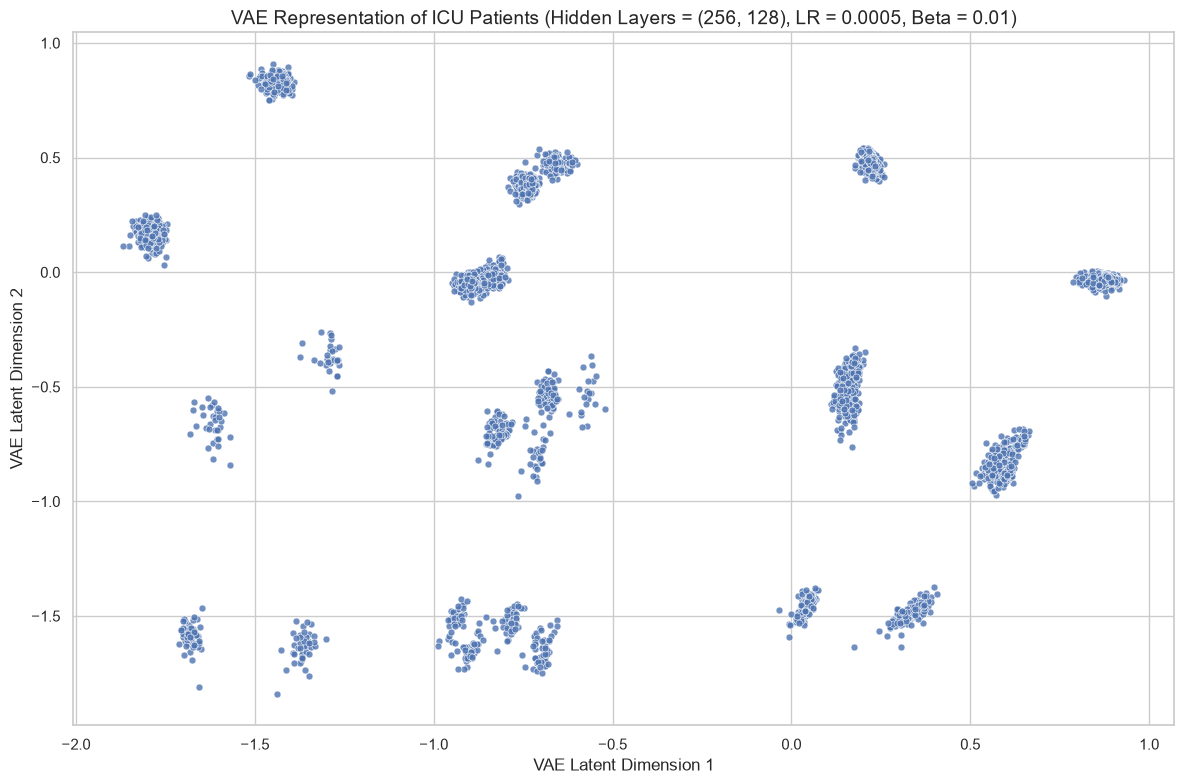

In [26]:
# Create the final 2D VAE scatter plot
plt.figure(figsize=(12, 8))

plt.scatter(
    vae_df["vae_1"],
    vae_df["vae_2"],
    s=25,
    edgecolors="white",
    linewidths=0.5,
    alpha=0.8
)

# Add axis labels
plt.xlabel("VAE Latent Dimension 1")
plt.ylabel("VAE Latent Dimension 2")

# Add title with selected VAE configuration
plt.title(
    f"VAE Representation of ICU Patients "
    f"(Hidden Layers = ({best_hidden_dim1}, {best_hidden_dim2}), "
    f"LR = {best_learning_rate}, "
    f"Beta = {best_beta})"
)

plt.tight_layout()

# Save plot
plt.savefig(
    PLOTS_DIR / "04.vae_embedding.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# KMeans Clustering

## Prepare Embeddings for KMeans 

In [27]:
# Prepare the four representations for KMeans clustering
clustering_embeddings = {
    "PCA": pca_embedding,
    "t-SNE": tsne_embedding,
    "UMAP": umap_embedding,
    "VAE": vae_embedding
}

# Define candidate numbers of clusters
k_values = list(range(3, 11))

# Display clustering input summary
print("=" * 70)
print("KMEANS INPUT REPRESENTATIONS")
print("=" * 70)

for method, embedding in clustering_embeddings.items():

    print(
        f"{method:<10}: "
        f"{embedding.shape[0]:,} patients × "
        f"{embedding.shape[1]} dimensions"
    )

print("-" * 70)
print(f"{'Candidate k Values':<10}: {k_values}")
print(f"{'Total Representations':<10}: {len(clustering_embeddings)}")
print("=" * 70)

KMEANS INPUT REPRESENTATIONS
PCA       : 7,859 patients × 25 dimensions
t-SNE     : 7,859 patients × 2 dimensions
UMAP      : 7,859 patients × 2 dimensions
VAE       : 7,859 patients × 2 dimensions
----------------------------------------------------------------------
Candidate k Values: [3, 4, 5, 6, 7, 8, 9, 10]
Total Representations: 4


## Run KMeans Across All Embeddings

In [28]:
# Store KMeans models, labels, and inertia
kmeans_models = {}
kmeans_labels = {}
kmeans_inertia = []

total_solutions = (
    len(clustering_embeddings)
    * len(k_values)
)

solution_number = 0

print("=" * 80)
print("KMEANS CLUSTERING ACROSS ALL REPRESENTATIONS")
print("=" * 80)

# Run KMeans for each representation
for method, embedding in clustering_embeddings.items():

    print(f"\n{method} REPRESENTATION")

    for k in k_values:

        solution_number += 1

        # Initialize and fit KMeans
        kmeans = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            random_state=RANDOM_SEED
        )

        labels = kmeans.fit_predict(
            embedding
        )

        # Store trained model
        kmeans_models[
            (method, k)
        ] = kmeans

        # Store cluster labels
        kmeans_labels[
            (method, k)
        ] = labels

        # Store inertia
        kmeans_inertia.append({
            "Method": method,
            "k": k,
            "Inertia": kmeans.inertia_
        })

        # Display progress
        print(
            f"[{solution_number:02d}/{total_solutions}] "
            f"k = {k:<2} | "
            f"Inertia = {kmeans.inertia_:.4f}"
        )

# Convert inertia results to DataFrame
kmeans_inertia_df = pd.DataFrame(
    kmeans_inertia
)

# Save inertia results
kmeans_inertia_df.to_csv(
    RESULTS_DIR / "12.kmeans_inertia.csv",
    index=False
)

# Display completion summary
print("\n" + "=" * 80)
print("KMEANS CLUSTERING COMPLETED")
print("=" * 80)
print(
    f"{'Representations Evaluated':<35}: "
    f"{len(clustering_embeddings)}"
)
print(
    f"{'Candidate k Values':<35}: "
    f"{len(k_values)}"
)
print(
    f"{'Total KMeans Solutions':<35}: "
    f"{len(kmeans_labels)}"
)
print("=" * 80)

KMEANS CLUSTERING ACROSS ALL REPRESENTATIONS

PCA REPRESENTATION
[01/32] k = 3  | Inertia = 8333.8269
[02/32] k = 4  | Inertia = 7415.8190
[03/32] k = 5  | Inertia = 6787.9615
[04/32] k = 6  | Inertia = 6272.7257
[05/32] k = 7  | Inertia = 5902.0052
[06/32] k = 8  | Inertia = 5535.1446
[07/32] k = 9  | Inertia = 5354.4978
[08/32] k = 10 | Inertia = 5203.7653

t-SNE REPRESENTATION
[09/32] k = 3  | Inertia = 2916142.5000
[10/32] k = 4  | Inertia = 2094247.3750
[11/32] k = 5  | Inertia = 1493206.8750
[12/32] k = 6  | Inertia = 1196334.1250
[13/32] k = 7  | Inertia = 987256.5625
[14/32] k = 8  | Inertia = 853474.4375
[15/32] k = 9  | Inertia = 730485.3750
[16/32] k = 10 | Inertia = 629970.8750

UMAP REPRESENTATION
[17/32] k = 3  | Inertia = 304222.6250
[18/32] k = 4  | Inertia = 160384.8125
[19/32] k = 5  | Inertia = 104748.4453
[20/32] k = 6  | Inertia = 68136.0469
[21/32] k = 7  | Inertia = 54825.7891
[22/32] k = 8  | Inertia = 44477.0273
[23/32] k = 9  | Inertia = 33246.2617
[24/32] k =

## Match Cluster Labels Across Embeddings

In [29]:
# Store matched cluster labels
matched_kmeans_labels = {}

print("=" * 70)
print("CLUSTER LABEL MATCHING")
print("=" * 70)

# Use PCA as the reference representation for each k
for k in k_values:

    # Keep PCA labels unchanged
    reference_labels = kmeans_labels[
        ("PCA", k)
    ]

    matched_kmeans_labels[
        ("PCA", k)
    ] = reference_labels.copy()

    # Match all other representations to PCA
    for method in ["t-SNE", "UMAP", "VAE"]:

        current_labels = kmeans_labels[
            (method, k)
        ]

        # Create cluster-overlap contingency table
        contingency_table = pd.crosstab(
            reference_labels,
            current_labels
        ).to_numpy()

        # Find optimal label correspondence
        row_ind, col_ind = linear_sum_assignment(
            -contingency_table
        )

        # Create mapping:
        # current method label -> PCA reference label
        label_mapping = {
            current: reference
            for reference, current
            in zip(row_ind, col_ind)
        }

        # Apply label mapping
        matched_labels = np.array([
            label_mapping[label]
            for label in current_labels
        ])

        matched_kmeans_labels[
            (method, k)
        ] = matched_labels

    print(
        f"k = {k:<2} | "
        f"PCA reference matched with "
        f"t-SNE, UMAP, and VAE"
    )

# Display completion summary
print("=" * 70)
print("CLUSTER LABEL MATCHING COMPLETED")
print("=" * 70)
print(
    f"{'Reference Representation':<35}: PCA"
)
print(
    f"{'Matching Algorithm':<35}: Hungarian Algorithm"
)
print(
    f"{'Matched Solutions':<35}: "
    f"{len(matched_kmeans_labels)}"
)
print("=" * 70)

CLUSTER LABEL MATCHING
k = 3  | PCA reference matched with t-SNE, UMAP, and VAE
k = 4  | PCA reference matched with t-SNE, UMAP, and VAE
k = 5  | PCA reference matched with t-SNE, UMAP, and VAE
k = 6  | PCA reference matched with t-SNE, UMAP, and VAE
k = 7  | PCA reference matched with t-SNE, UMAP, and VAE
k = 8  | PCA reference matched with t-SNE, UMAP, and VAE
k = 9  | PCA reference matched with t-SNE, UMAP, and VAE
k = 10 | PCA reference matched with t-SNE, UMAP, and VAE
CLUSTER LABEL MATCHING COMPLETED
Reference Representation           : PCA
Matching Algorithm                 : Hungarian Algorithm
Matched Solutions                  : 32


## Visualize KMeans Clustering Across Embeddings

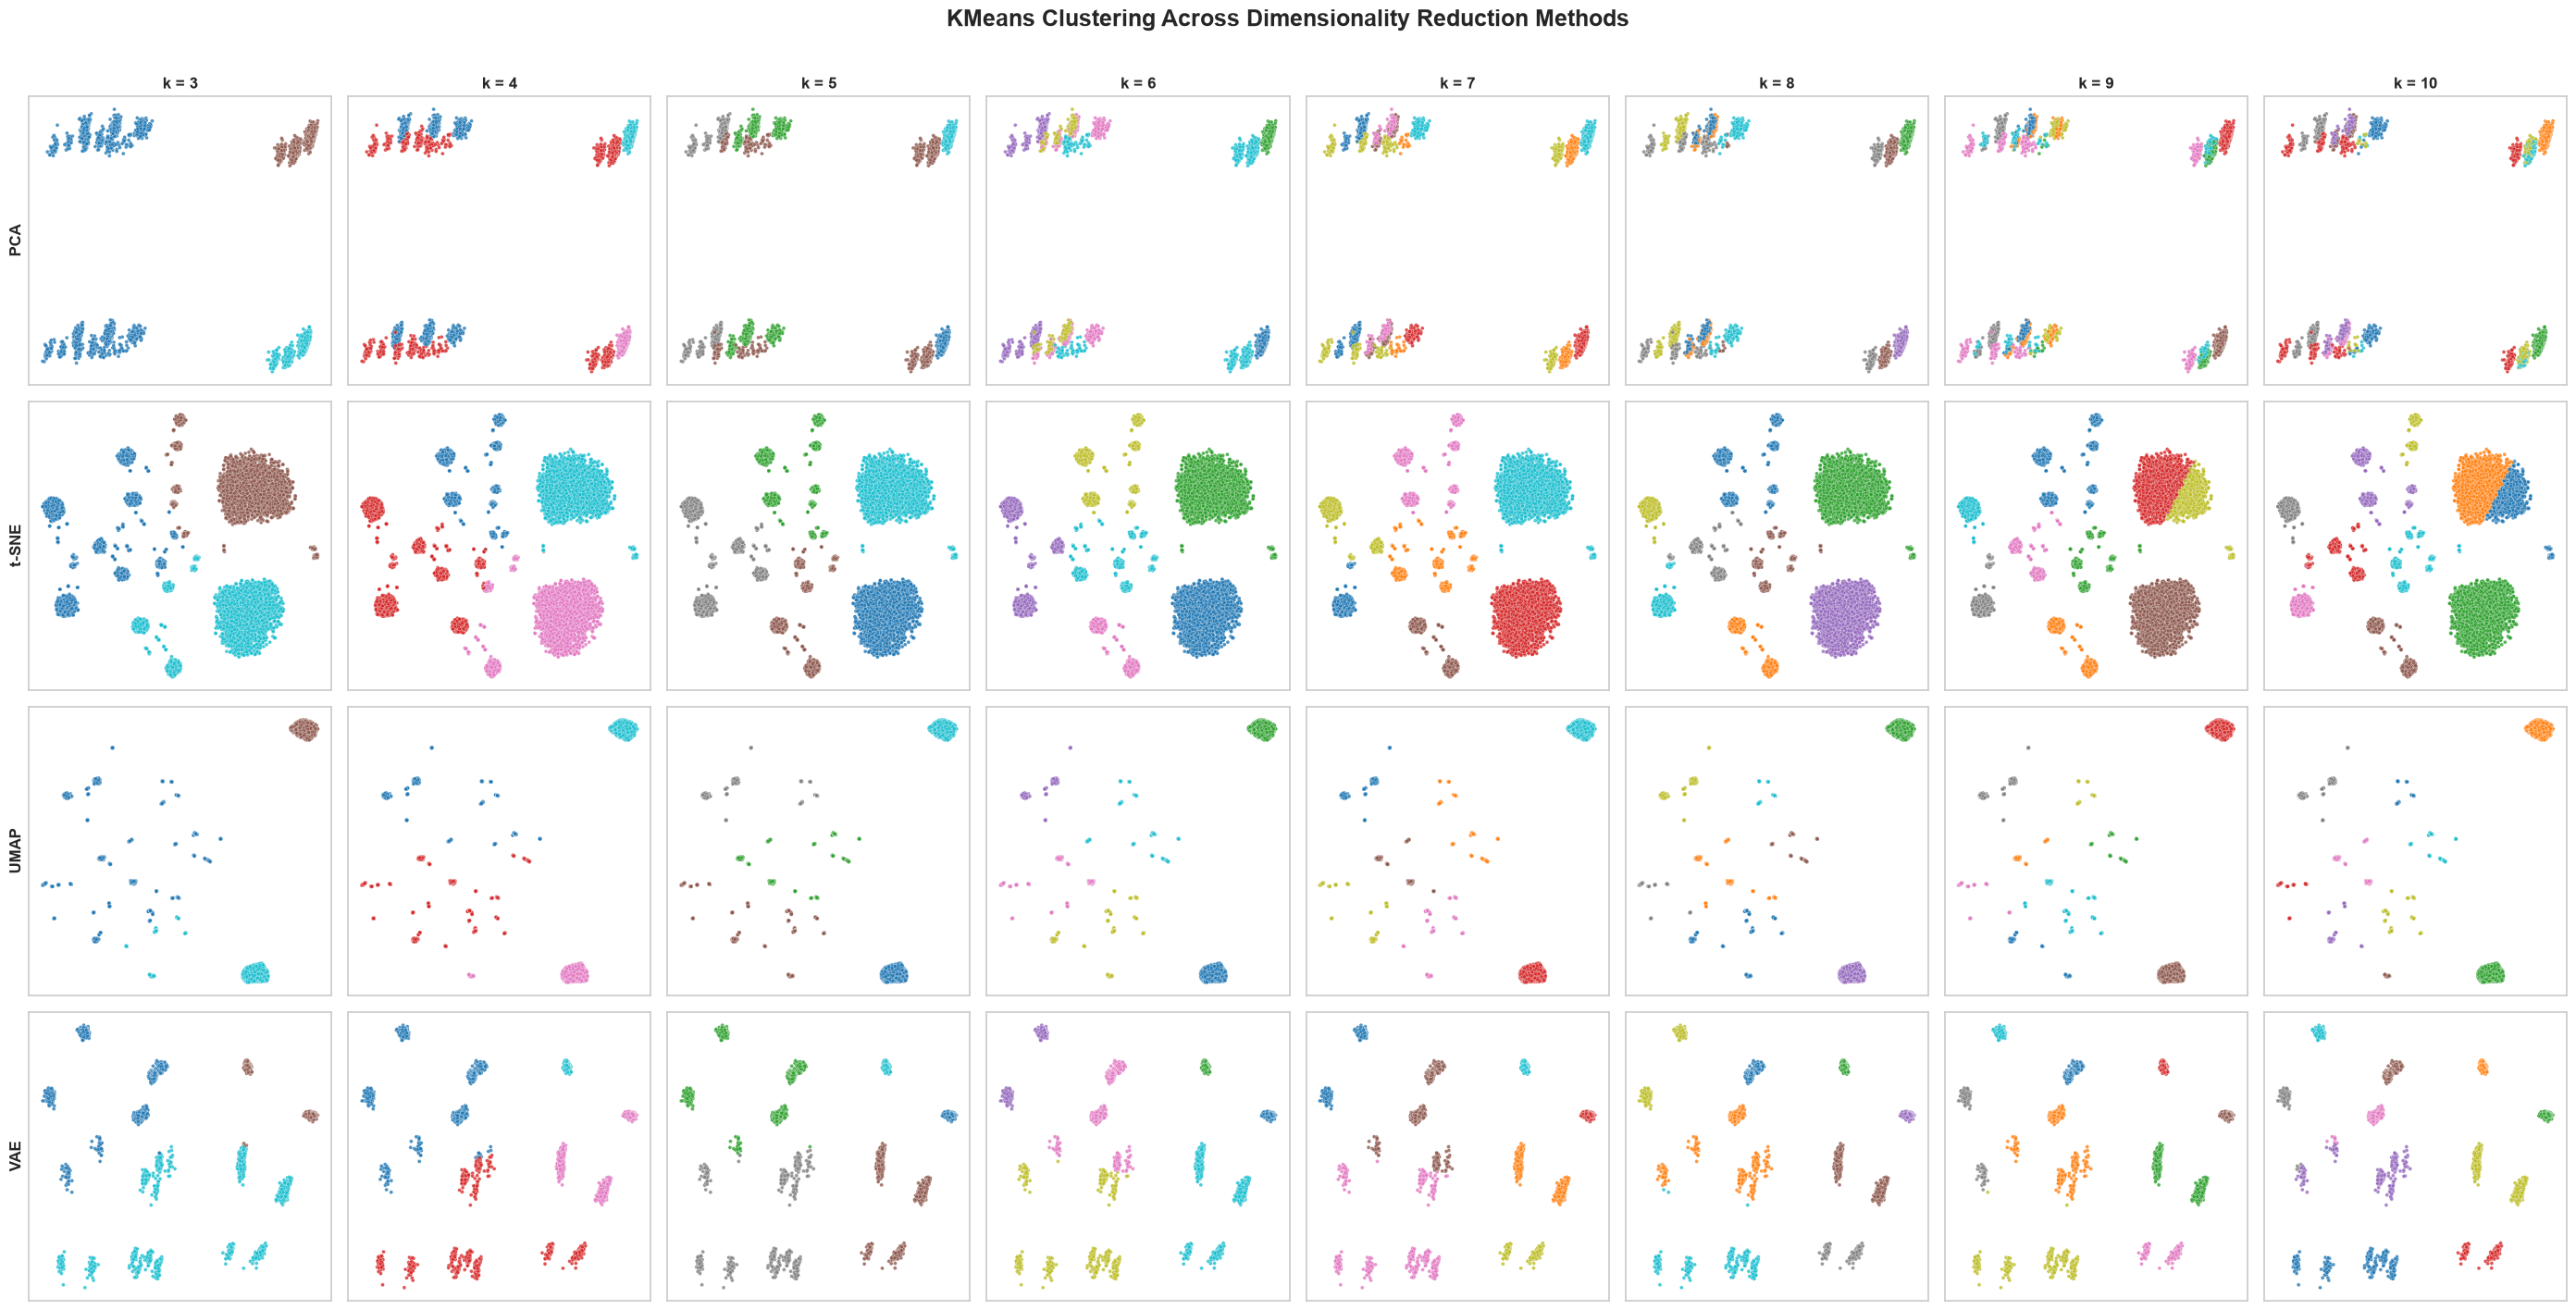

In [30]:
# Prepare 2D coordinates for visualization
plot_embeddings = {
    "PCA": pca_embedding[:, :2],
    "t-SNE": tsne_embedding,
    "UMAP": umap_embedding,
    "VAE": vae_embedding
}

methods = [
    "PCA",
    "t-SNE",
    "UMAP",
    "VAE"
]

# Create 4 × 8 comparison grid
fig, axes = plt.subplots(
    nrows=4,
    ncols=8,
    figsize=(28, 14)
)

# Plot each representation for k = 3 to 10
for row, method in enumerate(methods):

    coordinates = plot_embeddings[
        method
    ]

    for col, k in enumerate(k_values):

        ax = axes[row, col]

        # Use matched labels for consistent colors
        labels = matched_kmeans_labels[
            (method, k)
        ]

        # Create discrete colormap
        cmap = plt.get_cmap(
            "tab10",
            k
        )

        # Plot clustered representation
        ax.scatter(
            coordinates[:, 0],
            coordinates[:, 1],
            c=labels,
            cmap=cmap,
            s=8,
            alpha=0.8,
            edgecolors="white",
            linewidths=0.2
        )

        # Add k-value as column title
        if row == 0:
            ax.set_title(
                f"k = {k}",
                fontsize=12,
                fontweight="bold"
            )

        # Add method name as row label
        if col == 0:
            ax.set_ylabel(
                method,
                fontsize=12,
                fontweight="bold"
            )

        # Remove tick labels for cleaner comparison
        ax.set_xticks([])
        ax.set_yticks([])

# Add overall figure title
fig.suptitle(
    "KMeans Clustering Across Dimensionality Reduction Methods",
    fontsize=18,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()

# Save comparison figure
plt.savefig(
    PLOTS_DIR / "05.kmeans_embedding_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Cluster Validation

## Calculate Internal Validation Metrics

In [31]:
# Store cluster validation results
validation_results = []

# Define consistent method order
method_order = [
    "PCA",
    "t-SNE",
    "UMAP",
    "VAE"
]

print("=" * 90)
print("KMEANS INTERNAL VALIDATION")
print("=" * 90)

# Evaluate each k across all representations
for k in k_values:

    for method in method_order:

        embedding = clustering_embeddings[method]

        # Retrieve fitted KMeans model and labels
        labels = kmeans_labels[(method, k)]
        model = kmeans_models[(method, k)]

        # Silhouette Score
        silhouette = silhouette_score(
            embedding,
            labels,
            sample_size=2000,
            random_state=RANDOM_SEED
        )

        # Davies-Bouldin Index
        dbi = davies_bouldin_score(
            embedding,
            labels
        )

        # Calinski-Harabasz Score
        chi = calinski_harabasz_score(
            embedding,
            labels
        )

        # Store validation metrics
        validation_results.append({
            "k": k,
            "Method": method,
            "Inertia": model.inertia_,
            "Silhouette": silhouette,
            "Davies_Bouldin": dbi,
            "Calinski_Harabasz": chi
        })


# Convert results to DataFrame
validation_df = pd.DataFrame(
    validation_results
)

# Save original numeric results
validation_df.to_csv(
    RESULTS_DIR / "13.kmeans_validation_metrics.csv",
    index=False
)


# ---------------------------------------------------------
# Create formatted display table
# ---------------------------------------------------------

display_rows = []

for i, k in enumerate(k_values):

    # Select results for current k
    group = validation_df[
        validation_df["k"] == k
    ]

    # Add PCA, t-SNE, UMAP, and VAE rows
    for row_number, (_, row) in enumerate(group.iterrows()):

        display_rows.append({
            "k": str(k) if row_number == 0 else "",
            "Method": row["Method"],
            "Inertia": f"{row['Inertia']:.4f}",
            "Silhouette": f"{row['Silhouette']:.4f}",
            "Davies-Bouldin": f"{row['Davies_Bouldin']:.4f}",
            "Calinski-Harabasz": f"{row['Calinski_Harabasz']:.2f}"
        })

    # Add one blank row between k groups
    if i < len(k_values) - 1:

        display_rows.append({
            "k": "",
            "Method": "",
            "Inertia": "",
            "Silhouette": "",
            "Davies-Bouldin": "",
            "Calinski-Harabasz": ""
        })


# Create final display DataFrame
validation_display_df = pd.DataFrame(
    display_rows
)


# Display completion summary
print("=" * 90)
print("CLUSTER VALIDATION COMPLETED")
print("=" * 90)
print(
    f"{'Total Solutions Evaluated':<35}: "
    f"{len(validation_df)}"
)
print("=" * 90)


# Display formatted table
display(
    validation_display_df
    .style
    .hide(axis="index")
)

KMEANS INTERNAL VALIDATION
CLUSTER VALIDATION COMPLETED
Total Solutions Evaluated          : 32


k,Method,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
3,PCA,8333.8269,0.1940,1.7036,1637.68
,t-SNE,2916142.5000,0.5177,0.6518,10150.30
,UMAP,304222.6250,0.6801,0.4879,24979.76
,VAE,2238.1030,0.5883,0.7915,10044.70
,,,,,
4,PCA,7415.8190,0.2004,1.6954,1550.91
,t-SNE,2094247.3750,0.5205,0.7431,10448.99
,UMAP,160384.8125,0.6877,0.6341,33932.41
,VAE,1420.7971,0.6628,0.6007,12053.43
,,,,,


## Select the Best `k` for Each Embedding

In [32]:
# Copy validation results
ranked_validation_df = validation_df.copy()

# Rank Silhouette Score: higher is better
ranked_validation_df["Silhouette_Rank"] = (
    ranked_validation_df
    .groupby("Method")["Silhouette"]
    .rank(ascending=False)
)

# Rank Davies-Bouldin Index: lower is better
ranked_validation_df["DB_Rank"] = (
    ranked_validation_df
    .groupby("Method")["Davies_Bouldin"]
    .rank(ascending=True)
)

# Rank Calinski-Harabasz Score: higher is better
ranked_validation_df["CH_Rank"] = (
    ranked_validation_df
    .groupby("Method")["Calinski_Harabasz"]
    .rank(ascending=False)
)

# Calculate total rank
ranked_validation_df["Total_Rank"] = (
    ranked_validation_df["Silhouette_Rank"]
    + ranked_validation_df["DB_Rank"]
    + ranked_validation_df["CH_Rank"]
)

# Sort results by method and total rank
ranked_validation_df = (
    ranked_validation_df
    .sort_values(
        ["Method", "Total_Rank"]
    )
    .reset_index(drop=True)
)

# Select the best k for each embedding
best_k_by_method = (
    ranked_validation_df
    .loc[
        ranked_validation_df
        .groupby("Method")["Total_Rank"]
        .idxmin()
    ]
    .reset_index(drop=True)
)

# Preserve preferred method order
method_order = [
    "PCA",
    "t-SNE",
    "UMAP",
    "VAE"
]

best_k_by_method["Method"] = pd.Categorical(
    best_k_by_method["Method"],
    categories=method_order,
    ordered=True
)

best_k_by_method = (
    best_k_by_method
    .sort_values("Method")
    .reset_index(drop=True)
)

# Save ranked validation results
ranked_validation_df.to_csv(
    RESULTS_DIR / "14.kmeans_ranked_validation.csv",
    index=False
)

# Save selected best k values
best_k_by_method.to_csv(
    RESULTS_DIR / "15.best_k_by_embedding.csv",
    index=False
)

# Display results
print("=" * 90)
print("BEST k FOR EACH EMBEDDING")
print("=" * 90)

display(
    best_k_by_method[
        [
            "Method",
            "k",
            "Silhouette",
            "Davies_Bouldin",
            "Calinski_Harabasz",
        ]
    ]
    .style
    .format({
        "Silhouette": "{:.4f}",
        "Davies_Bouldin": "{:.4f}",
        "Calinski_Harabasz": "{:.2f}",
    })
    .hide(axis="index")
)

BEST k FOR EACH EMBEDDING


Method,k,Silhouette,Davies_Bouldin,Calinski_Harabasz
PCA,7,0.2765,1.5102,1309.64
t-SNE,8,0.5997,0.5814,12613.29
UMAP,10,0.7921,0.4549,80026.66
VAE,10,0.8775,0.4234,49031.05


## Evaluate Cluster Size Distribution

In [33]:
# =========================================================
# Calculate cluster sizes for ALL candidate KMeans solutions
# =========================================================

cluster_size_results = []

for method in method_order:

    for k in k_values:

        # Retrieve cluster labels
        labels = kmeans_labels[
            (method, k)
        ]

        # Count patients in each cluster
        cluster_counts = (
            pd.Series(labels)
            .value_counts()
            .sort_index()
        )

        # Store cluster-level statistics
        for cluster, count in cluster_counts.items():

            cluster_size_results.append({
                "Method": method,
                "k": k,
                "Cluster": int(cluster),
                "Patient_Count": int(count),
                "Percentage": (
                    count / len(labels)
                ) * 100
            })


# Convert to DataFrame
cluster_size_df = pd.DataFrame(
    cluster_size_results
)


# Save complete results for downstream analysis
cluster_size_df.to_csv(
    RESULTS_DIR / "16.cluster_size_distribution.csv",
    index=False
)


# =========================================================
# Create complete cluster-size summary for ALL k values
# =========================================================

cluster_size_summary = (
    cluster_size_df
    .groupby(
        ["Method", "k"],
        sort=False
    )
    .agg(
        Number_of_Clusters=(
            "Cluster",
            "nunique"
        ),
        Smallest_Cluster_Count=(
            "Patient_Count",
            "min"
        ),
        Largest_Cluster_Count=(
            "Patient_Count",
            "max"
        ),
        Smallest_Cluster_Percentage=(
            "Percentage",
            "min"
        ),
        Largest_Cluster_Percentage=(
            "Percentage",
            "max"
        )
    )
    .reset_index()
)


# =========================================================
# Extract only selected best-k solutions for DISPLAY
# =========================================================

selected_best_k = (
    best_k_by_method[
        ["Method", "k"]
    ]
    .copy()
)

selected_best_k["Method"] = (
    selected_best_k["Method"]
    .astype(str)
)


selected_cluster_sizes = (
    cluster_size_df
    .merge(
        selected_best_k,
        on=["Method", "k"],
        how="inner"
    )
)


selected_cluster_size_summary = (
    cluster_size_summary
    .merge(
        selected_best_k,
        on=["Method", "k"],
        how="inner"
    )
)


# Preserve preferred method order for display
selected_cluster_size_summary["Method"] = pd.Categorical(
    selected_cluster_size_summary["Method"],
    categories=method_order,
    ordered=True
)

selected_cluster_size_summary = (
    selected_cluster_size_summary
    .sort_values("Method")
    .reset_index(drop=True)
)


# =========================================================
# Display summary
# =========================================================

print("=" * 100)
print("CLUSTER SIZE DISTRIBUTION FOR SELECTED KMEANS SOLUTIONS")
print("=" * 100)

print(
    f"{'All KMeans Solutions Calculated':<38}: "
    f"{len(method_order) * len(k_values)}"
)

print(
    f"{'All Cluster Records Stored':<38}: "
    f"{len(cluster_size_df)}"
)

print(
    f"{'Selected Solutions Displayed':<38}: "
    f"{len(method_order)}"
)

print(
    f"{'Patients per Solution':<38}: "
    f"{len(patient_ids):,}"
)

print("=" * 100)

print("\nCLUSTER SIZE SUMMARY\n")


display(
    selected_cluster_size_summary
    .rename(columns={
        "k": "Selected k",
        "Number_of_Clusters": "Clusters",
        "Smallest_Cluster_Count": "Smallest Cluster",
        "Smallest_Cluster_Percentage": "Smallest %",
        "Largest_Cluster_Count": "Largest Cluster",
        "Largest_Cluster_Percentage": "Largest %"
    })
    [
        [
            "Method",
            "Selected k",
            "Clusters",
            "Smallest Cluster",
            "Smallest %",
            "Largest Cluster",
            "Largest %"
        ]
    ]
    .style
    .format({
        "Smallest Cluster": "{:,}",
        "Smallest %": "{:.2f}%",
        "Largest Cluster": "{:,}",
        "Largest %": "{:.2f}%"
    })
    .hide(axis="index")
)


# =========================================================
# Detailed distribution for selected solutions only
# =========================================================

display_rows = []

for i, method in enumerate(method_order):

    method_data = (
        selected_cluster_sizes[
            selected_cluster_sizes["Method"] == method
        ]
        .copy()
        .sort_values("Cluster")
    )

    selected_k = int(
        method_data["k"].iloc[0]
    )

    for row_number, (_, row) in enumerate(
        method_data.iterrows()
    ):

        display_rows.append({
            "Method": (
                method
                if row_number == 0
                else ""
            ),
            "Selected k": (
                selected_k
                if row_number == 0
                else ""
            ),
            "Cluster": int(
                row["Cluster"]
            ),
            "Patient Count": (
                f"{int(row['Patient_Count']):,}"
            ),
            "Percentage": (
                f"{row['Percentage']:.2f}%"
            )
        })

    # Add blank row between embeddings
    if i < len(method_order) - 1:

        display_rows.append({
            "Method": "",
            "Selected k": "",
            "Cluster": "",
            "Patient Count": "",
            "Percentage": ""
        })


cluster_size_display = pd.DataFrame(
    display_rows
)


print("\nDETAILED CLUSTER DISTRIBUTION\n")

display(
    cluster_size_display
    .style
    .hide(axis="index")
)

CLUSTER SIZE DISTRIBUTION FOR SELECTED KMEANS SOLUTIONS
All KMeans Solutions Calculated       : 32
All Cluster Records Stored            : 208
Selected Solutions Displayed          : 4
Patients per Solution                 : 7,859

CLUSTER SIZE SUMMARY



Method,Selected k,Clusters,Smallest Cluster,Smallest %,Largest Cluster,Largest %
PCA,7,7,521,6.63%,"2,385",30.35%
t-SNE,8,8,393,5.00%,"2,290",29.14%
UMAP,10,10,201,2.56%,"2,195",27.93%
VAE,10,10,254,3.23%,"2,195",27.93%



DETAILED CLUSTER DISTRIBUTION



Method,Selected k,Cluster,Patient Count,Percentage
PCA,7,0,778,9.90%
,,1,749,9.53%
,,2,"2,268",28.86%
,,3,533,6.78%
,,4,521,6.63%
,,5,625,7.95%
,,6,"2,385",30.35%
,,,,
t-SNE,8,0,555,7.06%
,,1,"2,290",29.14%


## Evaluate KMeans Stability Across Random Seeds

In [34]:
# =========================================================
# Random seeds for KMeans stability evaluation
# =========================================================

stability_seeds = [
    RANDOM_SEED,
    42,
    123,
    456,
    789
]

# Store pairwise ARI results
stability_results = []


# =========================================================
# Evaluate stability for ALL methods and ALL k values
# =========================================================

for method in method_order:

    embedding = clustering_embeddings[
        method
    ]

    for k in k_values:

        seed_labels = {}

        # Run KMeans using different random seeds
        for seed in stability_seeds:

            kmeans = KMeans(
                n_clusters=k,
                init="k-means++",
                n_init=10,
                random_state=seed
            )

            seed_labels[seed] = (
                kmeans.fit_predict(
                    embedding
                )
            )


        # Compare every pair of seed solutions
        for i in range(
            len(stability_seeds)
        ):

            for j in range(
                i + 1,
                len(stability_seeds)
            ):

                seed_1 = stability_seeds[i]
                seed_2 = stability_seeds[j]

                ari = adjusted_rand_score(
                    seed_labels[seed_1],
                    seed_labels[seed_2]
                )

                stability_results.append({
                    "Method": method,
                    "k": k,
                    "Seed_1": seed_1,
                    "Seed_2": seed_2,
                    "ARI": ari
                })


# =========================================================
# Create detailed stability DataFrame
# =========================================================

stability_df = pd.DataFrame(
    stability_results
)


# Save complete pairwise results
stability_df.to_csv(
    RESULTS_DIR / "19.kmeans_stability_pairwise.csv",
    index=False
)


# =========================================================
# Summarize stability for every method and k
# =========================================================

stability_summary = (
    stability_df
    .groupby(
        ["Method", "k"],
        sort=False
    )
    .agg(
        Mean_ARI=("ARI", "mean"),
        Std_ARI=("ARI", "std"),
        Min_ARI=("ARI", "min"),
        Max_ARI=("ARI", "max")
    )
    .reset_index()
)


# Save complete stability summary
stability_summary.to_csv(
    RESULTS_DIR / "20.kmeans_stability_summary.csv",
    index=False
)


# =========================================================
# Extract selected best-k solutions for DISPLAY
# =========================================================

selected_best_k = (
    best_k_by_method[
        ["Method", "k"]
    ]
    .copy()
)

selected_best_k["Method"] = (
    selected_best_k["Method"]
    .astype(str)
)


selected_stability_summary = (
    stability_summary
    .merge(
        selected_best_k,
        on=["Method", "k"],
        how="inner"
    )
)


# Preserve method order
selected_stability_summary["Method"] = pd.Categorical(
    selected_stability_summary["Method"],
    categories=method_order,
    ordered=True
)

selected_stability_summary = (
    selected_stability_summary
    .sort_values("Method")
    .reset_index(drop=True)
)


# =========================================================
# Display concise stability results
# =========================================================

print("=" * 100)
print("KMEANS STABILITY FOR SELECTED SOLUTIONS")
print("=" * 100)

print(
    f"{'All KMeans Solutions Evaluated':<38}: "
    f"{len(method_order) * len(k_values)}"
)

print(
    f"{'Random Seeds per Solution':<38}: "
    f"{len(stability_seeds)}"
)

print(
    f"{'Total Pairwise Comparisons':<38}: "
    f"{len(stability_df)}"
)

print(
    f"{'Selected Solutions Displayed':<38}: "
    f"{len(method_order)}"
)

print("=" * 100)


display(
    selected_stability_summary
    .rename(columns={
        "k": "Selected k",
        "Mean_ARI": "Mean ARI",
        "Std_ARI": "Std ARI",
        "Min_ARI": "Minimum ARI",
        "Max_ARI": "Maximum ARI"
    })
    [
        [
            "Method",
            "Selected k",
            "Mean ARI",
            "Std ARI",
            "Minimum ARI",
            "Maximum ARI"
        ]
    ]
    .style
    .format({
        "Mean ARI": "{:.4f}",
        "Std ARI": "{:.4f}",
        "Minimum ARI": "{:.4f}",
        "Maximum ARI": "{:.4f}"
    })
    .hide(axis="index")
)

KMEANS STABILITY FOR SELECTED SOLUTIONS
All KMeans Solutions Evaluated        : 32
Random Seeds per Solution             : 5
Total Pairwise Comparisons            : 320
Selected Solutions Displayed          : 4


Method,Selected k,Mean ARI,Std ARI,Minimum ARI,Maximum ARI
PCA,7,0.9508,0.0422,0.9048,1.0000
t-SNE,8,0.9274,0.0909,0.8207,1.0000
UMAP,10,1.0000,0.0000,1.0000,1.0000
VAE,10,0.9997,0.0002,0.9995,1.0000


## Evaluate Agreement Across Embeddings

In [35]:
# Embedding methods
methods = [
    "PCA",
    "t-SNE",
    "UMAP",
    "VAE"
]

# Store pairwise cross-embedding agreement
embedding_agreement_results = []

# Compare every pair of embeddings at the same k
for k in k_values:

    for i in range(len(methods)):

        for j in range(i + 1, len(methods)):

            method_1 = methods[i]
            method_2 = methods[j]

            # Retrieve KMeans cluster labels
            labels_1 = kmeans_labels[
                (method_1, k)
            ]

            labels_2 = kmeans_labels[
                (method_2, k)
            ]

            # Calculate Adjusted Rand Index
            ari = adjusted_rand_score(
                labels_1,
                labels_2
            )

            # Store result
            embedding_agreement_results.append({
                "k": k,
                "Method_1": method_1,
                "Method_2": method_2,
                "ARI": ari
            })


# Convert detailed results to DataFrame
embedding_agreement_df = pd.DataFrame(
    embedding_agreement_results
)


# Save detailed pairwise results
embedding_agreement_df.to_csv(
    RESULTS_DIR / "21.embedding_pairwise_ari.csv",
    index=False
)


# =========================================================
# Summarize cross-embedding agreement by k
# =========================================================

embedding_agreement_summary = (
    embedding_agreement_df
    .groupby("k")
    .agg(
        Mean_ARI=("ARI", "mean"),
        Std_ARI=("ARI", "std"),
        Min_ARI=("ARI", "min"),
        Max_ARI=("ARI", "max")
    )
    .reset_index()
)


# Save agreement summary
embedding_agreement_summary.to_csv(
    RESULTS_DIR / "22.embedding_agreement_summary.csv",
    index=False
)


# Identify k with highest mean cross-embedding agreement
best_agreement_row = (
    embedding_agreement_summary
    .loc[
        embedding_agreement_summary[
            "Mean_ARI"
        ].idxmax()
    ]
)

best_agreement_k = int(
    best_agreement_row["k"]
)


# =========================================================
# Display concise results
# =========================================================

print("=" * 90)
print("CROSS-EMBEDDING CLUSTER AGREEMENT")
print("=" * 90)

print(
    f"{'Embedding Methods':<35}: "
    f"{len(methods)}"
)

print(
    f"{'Candidate k Values':<35}: "
    f"{len(k_values)}"
)

print(
    f"{'Pairwise Comparisons':<35}: "
    f"{len(embedding_agreement_df)}"
)

print(
    f"{'Strongest Agreement at k':<35}: "
    f"{best_agreement_k}"
)

print("=" * 90)


# Display only summarized agreement
display(
    embedding_agreement_summary
    .rename(columns={
        "k": "k",
        "Mean_ARI": "Mean ARI",
        "Std_ARI": "Std ARI",
        "Min_ARI": "Minimum ARI",
        "Max_ARI": "Maximum ARI"
    })
    .style
    .format({
        "Mean ARI": "{:.4f}",
        "Std ARI": "{:.4f}",
        "Minimum ARI": "{:.4f}",
        "Maximum ARI": "{:.4f}"
    })
    .hide(axis="index")
)

CROSS-EMBEDDING CLUSTER AGREEMENT
Embedding Methods                  : 4
Candidate k Values                 : 8
Pairwise Comparisons               : 48
Strongest Agreement at k           : 8


k,Mean ARI,Std ARI,Minimum ARI,Maximum ARI
3,0.4233,0.1001,0.2527,0.5464
4,0.6562,0.0849,0.5894,0.8091
5,0.7789,0.0512,0.7085,0.8591
6,0.8469,0.0365,0.8046,0.9119
7,0.8261,0.0183,0.7967,0.8424
8,0.8826,0.0292,0.8470,0.9236
9,0.8286,0.0757,0.7470,0.9173
10,0.8451,0.0681,0.7699,0.9251


## Summarize Evidence Across Candidate Values of `k`

In [36]:
# =========================================================
# 1. Internal validation evidence
# =========================================================

validation_ranked = validation_df.copy()

# Higher Silhouette Score is better
validation_ranked["Silhouette_Rank"] = (
    validation_ranked
    .groupby("Method")["Silhouette"]
    .rank(ascending=False)
)

# Lower Davies-Bouldin Index is better
validation_ranked["Davies_Bouldin_Rank"] = (
    validation_ranked
    .groupby("Method")["Davies_Bouldin"]
    .rank(ascending=True)
)

# Higher Calinski-Harabasz Score is better
validation_ranked["Calinski_Harabasz_Rank"] = (
    validation_ranked
    .groupby("Method")["Calinski_Harabasz"]
    .rank(ascending=False)
)

# Average internal validation rank
validation_ranked["Internal_Validation_Rank"] = (
    validation_ranked[
        [
            "Silhouette_Rank",
            "Davies_Bouldin_Rank",
            "Calinski_Harabasz_Rank"
        ]
    ]
    .mean(axis=1)
)


# Summarize internal validation across embeddings
validation_k_summary = (
    validation_ranked
    .groupby("k")
    .agg(
        Mean_Internal_Validation_Rank=(
            "Internal_Validation_Rank",
            "mean"
        )
    )
    .reset_index()
)


# =========================================================
# 2. KMeans stability evidence
# =========================================================

stability_k_summary = (
    stability_summary
    .groupby("k")
    .agg(
        Mean_Stability_ARI=(
            "Mean_ARI",
            "mean"
        )
    )
    .reset_index()
)


# =========================================================
# 3. Cluster-size evidence
# =========================================================

size_k_summary = (
    cluster_size_summary
    .groupby("k")
    .agg(
        Mean_Smallest_Cluster_Percentage=(
            "Smallest_Cluster_Percentage",
            "mean"
        ),
        Minimum_Cluster_Percentage=(
            "Smallest_Cluster_Percentage",
            "min"
        )
    )
    .reset_index()
)


# =========================================================
# 4. Combine all evidence
# =========================================================

k_evidence_summary = (
    validation_k_summary
    .merge(
        stability_k_summary,
        on="k"
    )
    .merge(
        embedding_agreement_summary[
            ["k", "Mean_ARI"]
        ],
        on="k"
    )
    .merge(
        size_k_summary,
        on="k"
    )
)


# Rename cross-embedding agreement column
k_evidence_summary = (
    k_evidence_summary
    .rename(columns={
        "Mean_ARI":
            "Mean_Cross_Embedding_ARI"
    })
)


# =========================================================
# 5. Rank each evidence category
# =========================================================

# Lower validation rank is better
k_evidence_summary["Validation_Rank"] = (
    k_evidence_summary[
        "Mean_Internal_Validation_Rank"
    ]
    .rank(ascending=True)
)

# Higher stability is better
k_evidence_summary["Stability_Rank"] = (
    k_evidence_summary[
        "Mean_Stability_ARI"
    ]
    .rank(ascending=False)
)

# Higher cross-embedding agreement is better
k_evidence_summary["Agreement_Rank"] = (
    k_evidence_summary[
        "Mean_Cross_Embedding_ARI"
    ]
    .rank(ascending=False)
)

# Larger minimum cluster percentage is better
k_evidence_summary["Size_Rank"] = (
    k_evidence_summary[
        "Minimum_Cluster_Percentage"
    ]
    .rank(ascending=False)
)


# =========================================================
# 6. Calculate overall evidence rank
# =========================================================

k_evidence_summary["Overall_Evidence_Rank"] = (
    k_evidence_summary[
        [
            "Validation_Rank",
            "Stability_Rank",
            "Agreement_Rank",
            "Size_Rank"
        ]
    ]
    .mean(axis=1)
)


# Sort strongest to weakest combined evidence
k_evidence_summary = (
    k_evidence_summary
    .sort_values(
        "Overall_Evidence_Rank"
    )
    .reset_index(drop=True)
)


# Save complete evidence table
k_evidence_summary.to_csv(
    RESULTS_DIR / "23.k_selection_evidence_summary.csv",
    index=False
)


# =========================================================
# Display concise evidence summary
# =========================================================

print("=" * 110)
print("COMBINED EVIDENCE ACROSS CANDIDATE k VALUES")
print("=" * 110)

print(
    f"{'Candidate k Values Evaluated':<40}: "
    f"{len(k_evidence_summary)}"
)

print(
    f"{'Evidence Categories':<40}: "
    f"{4}"
)

print("=" * 110)


display(
    k_evidence_summary[
        [
            "k",
            "Mean_Internal_Validation_Rank",
            "Mean_Stability_ARI",
            "Mean_Cross_Embedding_ARI",
            "Minimum_Cluster_Percentage",
            "Overall_Evidence_Rank"
        ]
    ]
    .rename(columns={
        "Mean_Internal_Validation_Rank":
            "Internal Validation Rank",
        "Mean_Stability_ARI":
            "Stability ARI",
        "Mean_Cross_Embedding_ARI":
            "Cross-Embedding ARI",
        "Minimum_Cluster_Percentage":
            "Minimum Cluster %",
        "Overall_Evidence_Rank":
            "Overall Evidence Rank"
    })
    .style
    .format({
        "Internal Validation Rank": "{:.4f}",
        "Stability ARI": "{:.4f}",
        "Cross-Embedding ARI": "{:.4f}",
        "Minimum Cluster %": "{:.2f}%",
        "Overall Evidence Rank": "{:.2f}"
    })
    .hide(axis="index")
)

COMBINED EVIDENCE ACROSS CANDIDATE k VALUES
Candidate k Values Evaluated            : 8
Evidence Categories                     : 4


k,Internal Validation Rank,Stability ARI,Cross-Embedding ARI,Minimum Cluster %,Overall Evidence Rank
6,4.9167,0.9858,0.8469,5.37%,3.75
3,6.5000,1.0000,0.4233,19.35%,4.50
4,6.1667,0.9998,0.6562,10.36%,4.50
5,6.0833,0.9916,0.7789,6.53%,4.50
8,3.1667,0.9494,0.8826,3.02%,4.50
9,3.0000,0.9762,0.8286,2.68%,4.50
10,2.4167,0.9726,0.8451,2.56%,4.75
7,3.7500,0.9753,0.8261,4.45%,5.00


## Select the Final Number of Clusters

In [37]:
# Select the strongest overall k
final_k_evidence = (
    k_evidence_summary
    .iloc[[0]]
    .copy()
)

# Extract final number of clusters
final_k = int(
    final_k_evidence["k"].iloc[0]
)

# Save final selection
final_k_evidence.to_csv(
    RESULTS_DIR / "24.final_k_selection.csv",
    index=False
)


# =========================================================
# Display final selection
# =========================================================

print("=" * 90)
print("FINAL NUMBER OF CLUSTERS")
print("=" * 90)

print(
    f"{'Selected Final k':<40}: "
    f"{final_k}"
)

print(
    f"{'Internal Validation Rank':<40}: "
    f"{final_k_evidence['Mean_Internal_Validation_Rank'].iloc[0]:.4f}"
)

print(
    f"{'Mean Stability ARI':<40}: "
    f"{final_k_evidence['Mean_Stability_ARI'].iloc[0]:.4f}"
)

print(
    f"{'Mean Cross-Embedding ARI':<40}: "
    f"{final_k_evidence['Mean_Cross_Embedding_ARI'].iloc[0]:.4f}"
)

print(
    f"{'Minimum Cluster Percentage':<40}: "
    f"{final_k_evidence['Minimum_Cluster_Percentage'].iloc[0]:.2f}%"
)

print(
    f"{'Overall Evidence Rank':<40}: "
    f"{final_k_evidence['Overall_Evidence_Rank'].iloc[0]:.2f}"
)

print("=" * 90)

FINAL NUMBER OF CLUSTERS
Selected Final k                        : 6
Internal Validation Rank                : 4.9167
Mean Stability ARI                      : 0.9858
Mean Cross-Embedding ARI                : 0.8469
Minimum Cluster Percentage              : 5.37%
Overall Evidence Rank                   : 3.75


# Final Cluster Solution

## Save Final Cluster Assignments

In [38]:
# Create final patient-level cluster assignment table
final_cluster_assignments = pd.DataFrame({

    "patientunitstayid": patient_ids,

    # Original KMeans cluster labels
    "PCA_Cluster":
        kmeans_labels[("PCA", final_k)],

    "tSNE_Cluster":
        kmeans_labels[("t-SNE", final_k)],

    "UMAP_Cluster":
        kmeans_labels[("UMAP", final_k)],

    "VAE_Cluster":
        kmeans_labels[("VAE", final_k)],


    # Cluster labels matched to PCA
    "PCA_Matched":
        matched_kmeans_labels[("PCA", final_k)],

    "tSNE_Matched":
        matched_kmeans_labels[("t-SNE", final_k)],

    "UMAP_Matched":
        matched_kmeans_labels[("UMAP", final_k)],

    "VAE_Matched":
        matched_kmeans_labels[("VAE", final_k)]
})


# Save final cluster assignments
final_cluster_assignments.to_csv(
    RESULTS_DIR /
    f"25.final_cluster_assignments_k{final_k}.csv",
    index=False
)


# =========================================================
# Display summary
# =========================================================

print("=" * 90)
print("FINAL CLUSTER ASSIGNMENTS")
print("=" * 90)

print(
    f"{'Final Number of Clusters':<35}: "
    f"{final_k}"
)

print(
    f"{'Number of Patients':<35}: "
    f"{len(final_cluster_assignments):,}"
)

print(
    f"{'Embedding Methods':<35}: "
    f"{len(method_order)}"
)

print("=" * 90)


# Preview patient-level assignments
display(
    final_cluster_assignments
    .head(20)
    .style
    .hide(axis="index")
)

FINAL CLUSTER ASSIGNMENTS
Final Number of Clusters           : 6
Number of Patients                 : 7,859
Embedding Methods                  : 4


patientunitstayid,PCA_Cluster,tSNE_Cluster,UMAP_Cluster,VAE_Cluster,PCA_Matched,tSNE_Matched,UMAP_Matched,VAE_Matched
151900,2,3,0,5,2,2,2,2
165269,2,3,0,0,2,2,2,3
179269,0,0,1,1,0,0,0,0
172764,0,0,1,1,0,0,0,0
215156,0,0,1,1,0,0,0,0
166175,1,2,2,2,1,1,1,1
211974,2,3,0,5,2,2,2,2
175631,3,5,3,0,3,4,5,3
205928,0,0,1,1,0,0,0,0
162841,0,0,1,1,0,0,0,0


## Create Cross-Embedding Consensus Labels

In [39]:
# Cluster labels matched to the PCA reference
matched_columns = [
    "PCA_Matched",
    "tSNE_Matched",
    "UMAP_Matched",
    "VAE_Matched"
]


# Create consensus dataset
consensus_df = final_cluster_assignments[
    ["patientunitstayid"] + matched_columns
].copy()


# =========================================================
# Define consensus assignment rule
# =========================================================

def get_consensus_label(row):

    # Count votes received by each cluster
    vote_counts = row.value_counts()

    # Identify cluster with the highest number of votes
    winning_cluster = vote_counts.idxmax()
    maximum_votes = vote_counts.max()

    # Require agreement from at least 3 of 4 methods
    if maximum_votes >= 3:
        return winning_cluster

    # Otherwise leave patient unassigned
    return np.nan


# =========================================================
# Assign consensus clusters
# =========================================================

consensus_df["Consensus_Cluster"] = (
    consensus_df[
        matched_columns
    ]
    .apply(
        get_consensus_label,
        axis=1
    )
)


# Count votes supporting each consensus assignment
consensus_df["Consensus_Votes"] = (
    consensus_df.apply(
        lambda row: (
            sum(
                row[column]
                == row["Consensus_Cluster"]
                for column in matched_columns
            )
            if pd.notna(
                row["Consensus_Cluster"]
            )
            else 0
        ),
        axis=1
    )
)


# Calculate consensus confidence
consensus_df["Consensus_Confidence"] = (
    consensus_df["Consensus_Votes"] / 4
)


# Store consensus labels as nullable integers
consensus_df["Consensus_Cluster"] = (
    consensus_df["Consensus_Cluster"]
    .astype("Int64")
)


# Save consensus labels
consensus_df.to_csv(
    RESULTS_DIR /
    "26.cross_embedding_consensus_labels.csv",
    index=False
)


# =========================================================
# Display summary
# =========================================================

patients_with_consensus = (
    consensus_df[
        "Consensus_Cluster"
    ]
    .notna()
    .sum()
)

patients_without_consensus = (
    consensus_df[
        "Consensus_Cluster"
    ]
    .isna()
    .sum()
)

consensus_rate = (
    patients_with_consensus
    / len(consensus_df)
) * 100


print("=" * 90)
print("CROSS-EMBEDDING CONSENSUS CLUSTERING")
print("=" * 90)

print(
    f"{'Total Patients':<40}: "
    f"{len(consensus_df):,}"
)

print(
    f"{'Patients With Consensus':<40}: "
    f"{patients_with_consensus:,}"
)

print(
    f"{'Patients Without Consensus':<40}: "
    f"{patients_without_consensus:,}"
)

print(
    f"{'Consensus Assignment Rate':<40}: "
    f"{consensus_rate:.2f}%"
)

print(
    f"{'Required Agreement':<40}: "
    f"3 of 4 methods"
)

print("=" * 90)


# Preview consensus assignments
display(
    consensus_df
    .head(10)
    .style
    .format({
        "Consensus_Confidence": "{:.2f}"
    })
    .hide(axis="index")
)

CROSS-EMBEDDING CONSENSUS CLUSTERING
Total Patients                          : 7,859
Patients With Consensus                 : 6,994
Patients Without Consensus              : 865
Consensus Assignment Rate               : 88.99%
Required Agreement                      : 3 of 4 methods


patientunitstayid,PCA_Matched,tSNE_Matched,UMAP_Matched,VAE_Matched,Consensus_Cluster,Consensus_Votes,Consensus_Confidence
151900,2,2,2,2,2,4,1.00
165269,2,2,2,3,2,3,0.75
179269,0,0,0,0,0,4,1.00
172764,0,0,0,0,0,4,1.00
215156,0,0,0,0,0,4,1.00
166175,1,1,1,1,1,4,1.00
211974,2,2,2,2,2,4,1.00
175631,3,4,5,3,,0,0.00
205928,0,0,0,0,0,4,1.00
162841,0,0,0,0,0,4,1.00


## Analyze Consensus Agreement and Non-Consensus Patients

In [40]:
# =========================================================
# Classify agreement pattern for each patient
# =========================================================

def get_agreement_pattern(row):

    # Count votes for each cluster
    vote_counts = (
        row[matched_columns]
        .value_counts()
    )

    # Sort vote counts from highest to lowest
    vote_pattern = sorted(
        vote_counts.tolist(),
        reverse=True
    )

    if vote_pattern == [4]:
        return "4-0 Agreement"

    elif vote_pattern == [3, 1]:
        return "3-1 Agreement"

    elif vote_pattern == [2, 2]:
        return "2-2 Tie"

    elif vote_pattern == [2, 1, 1]:
        return "2-1-1 Agreement"

    elif vote_pattern == [1, 1, 1, 1]:
        return "1-1-1-1 Tie"

    return "Other"


# Apply agreement classification
consensus_df["Agreement_Pattern"] = (
    consensus_df[matched_columns]
    .apply(
        get_agreement_pattern,
        axis=1
    )
)


# Identify patients without consensus
consensus_df["No_Consensus"] = (
    consensus_df[
        "Consensus_Cluster"
    ]
    .isna()
)


# Identify actual ties
consensus_df["Has_Tie"] = (
    consensus_df[
        "Agreement_Pattern"
    ]
    .isin([
        "2-2 Tie",
        "1-1-1-1 Tie"
    ])
)


# =========================================================
# Summarize agreement patterns
# =========================================================

agreement_summary = (
    consensus_df[
        "Agreement_Pattern"
    ]
    .value_counts()
    .rename_axis(
        "Agreement Pattern"
    )
    .reset_index(
        name="Patient Count"
    )
)


agreement_summary["Percentage"] = (
    agreement_summary[
        "Patient Count"
    ]
    / len(consensus_df)
    * 100
)


# =========================================================
# Analyze only patients without consensus
# =========================================================

no_consensus_df = (
    consensus_df[
        consensus_df["No_Consensus"]
    ]
    .copy()
)


no_consensus_summary = (
    no_consensus_df[
        "Agreement_Pattern"
    ]
    .value_counts()
    .rename_axis(
        "Reason"
    )
    .reset_index(
        name="Patient Count"
    )
)


no_consensus_summary[
    "Percentage of Non-Consensus"
] = (
    no_consensus_summary[
        "Patient Count"
    ]
    / len(no_consensus_df)
    * 100
)


# =========================================================
# Save original notebook outputs
# =========================================================

agreement_summary.to_csv(
    RESULTS_DIR /
    "27.consensus_agreement_summary.csv",
    index=False
)


consensus_ties_df = (
    consensus_df[
        consensus_df["Has_Tie"]
    ]
    .copy()
)


consensus_ties_df.to_csv(
    RESULTS_DIR /
    "28.consensus_tied_patients.csv",
    index=False
)


# =========================================================
# Display results
# =========================================================

print("=" * 90)
print("CONSENSUS AGREEMENT ANALYSIS")
print("=" * 90)

print(
    f"{'Total Patients':<40}: "
    f"{len(consensus_df):,}"
)

print(
    f"{'Patients With Consensus':<40}: "
    f"{(~consensus_df['No_Consensus']).sum():,}"
)

print(
    f"{'Patients Without Consensus':<40}: "
    f"{consensus_df['No_Consensus'].sum():,}"
)

print("=" * 90)

print("\nOVERALL AGREEMENT PATTERNS\n")

display(
    agreement_summary
    .style
    .format({
        "Patient Count": "{:,}",
        "Percentage": "{:.2f}%"
    })
    .hide(axis="index")
)


print("\nWHY PATIENTS HAVE NO CONSENSUS\n")

display(
    no_consensus_summary
    .style
    .format({
        "Patient Count": "{:,}",
        "Percentage of Non-Consensus": "{:.2f}%"
    })
    .hide(axis="index")
)


print("\nEXAMPLE PATIENTS WITHOUT CONSENSUS\n")

display(
    no_consensus_df[
        [
            "patientunitstayid",
            "PCA_Matched",
            "tSNE_Matched",
            "UMAP_Matched",
            "VAE_Matched",
            "Agreement_Pattern"
        ]
    ]
    .head(10)
    .style
    .hide(axis="index")
)

CONSENSUS AGREEMENT ANALYSIS
Total Patients                          : 7,859
Patients With Consensus                 : 6,994
Patients Without Consensus              : 865

OVERALL AGREEMENT PATTERNS



Agreement Pattern,Patient Count,Percentage
4-0 Agreement,"5,756",73.24%
3-1 Agreement,"1,238",15.75%
2-2 Tie,508,6.46%
2-1-1 Agreement,357,4.54%



WHY PATIENTS HAVE NO CONSENSUS



Reason,Patient Count,Percentage of Non-Consensus
2-2 Tie,508,58.73%
2-1-1 Agreement,357,41.27%



EXAMPLE PATIENTS WITHOUT CONSENSUS



patientunitstayid,PCA_Matched,tSNE_Matched,UMAP_Matched,VAE_Matched,Agreement_Pattern
175631,3,4,5,3,2-1-1 Agreement
191659,5,5,3,4,2-1-1 Agreement
220457,2,2,5,4,2-1-1 Agreement
238456,3,1,4,3,2-1-1 Agreement
183740,2,2,5,4,2-1-1 Agreement
171035,3,4,4,3,2-2 Tie
204579,3,4,4,3,2-2 Tie
219287,3,3,5,4,2-1-1 Agreement
160927,3,4,5,3,2-1-1 Agreement
234501,3,4,5,3,2-1-1 Agreement


## Create the High-Confidence Consensus Dataset

In [41]:
# Keep only patients where at least 3 of 4 embedding methods agree
high_confidence_consensus_df = consensus_df[
    consensus_df["Consensus_Confidence"] >= 0.75
].copy()

# Convert accepted consensus labels from nullable integer to standard integer
high_confidence_consensus_df["Consensus_Cluster"] = (
    high_confidence_consensus_df["Consensus_Cluster"]
    .astype(int)
)

# Count patients in each final consensus cluster
high_confidence_cluster_summary = (
    high_confidence_consensus_df["Consensus_Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Consensus Cluster")
    .reset_index(name="Patient Count")
)

# Calculate each cluster's percentage among high-confidence patients
high_confidence_cluster_summary["Percentage"] = (
    high_confidence_cluster_summary["Patient Count"]
    / len(high_confidence_consensus_df)
    * 100
)

# Save patient-level high-confidence consensus assignments
high_confidence_consensus_df.to_csv(
    RESULTS_DIR / "29.high_confidence_consensus_dataset.csv",
    index=False
)

# Save final consensus cluster-size distribution
high_confidence_cluster_summary.to_csv(
    RESULTS_DIR / "30.high_confidence_consensus_cluster_sizes.csv",
    index=False
)

# Calculate summary statistics
high_confidence_patients = len(high_confidence_consensus_df)
excluded_patients = len(consensus_df) - high_confidence_patients
high_confidence_percentage = (
    high_confidence_patients / len(consensus_df) * 100
)
final_consensus_clusters = (
    high_confidence_consensus_df["Consensus_Cluster"].nunique()
)

# Display high-confidence consensus summary
print("=" * 90)
print("HIGH-CONFIDENCE CONSENSUS DATASET")
print("=" * 90)
print(f"{'Total Patients':<40}: {len(consensus_df):,}")
print(f"{'High-Confidence Patients':<40}: {high_confidence_patients:,}")
print(f"{'High-Confidence Percentage':<40}: {high_confidence_percentage:.2f}%")
print(f"{'Patients Excluded':<40}: {excluded_patients:,}")
print(f"{'Final Consensus Clusters':<40}: {final_consensus_clusters}")
print("=" * 90)

print("\nFINAL CONSENSUS CLUSTER DISTRIBUTION\n")

display(
    high_confidence_cluster_summary
    .style
    .format({
        "Patient Count": "{:,}",
        "Percentage": "{:.2f}%"
    })
    .hide(axis="index")
)

HIGH-CONFIDENCE CONSENSUS DATASET
Total Patients                          : 7,859
High-Confidence Patients                : 6,994
High-Confidence Percentage              : 88.99%
Patients Excluded                       : 865
Final Consensus Clusters                : 6

FINAL CONSENSUS CLUSTER DISTRIBUTION



Consensus Cluster,Patient Count,Percentage
0,"2,118",30.28%
1,"2,195",31.38%
2,778,11.12%
3,552,7.89%
4,523,7.48%
5,828,11.84%


## Compare Final Solutions Across Embeddings

In [42]:
# Extract internal validation metrics at the final k
final_method_comparison = validation_df[
    validation_df["k"] == final_k
][
    [
        "Method",
        "Silhouette",
        "Davies_Bouldin",
        "Calinski_Harabasz"
    ]
].copy()

# Add KMeans stability metrics at the final k
final_method_comparison = final_method_comparison.merge(
    stability_summary[
        stability_summary["k"] == final_k
    ][
        [
            "Method",
            "Mean_ARI",
            "Min_ARI"
        ]
    ],
    on="Method"
)

final_method_comparison = final_method_comparison.rename(
    columns={
        "Mean_ARI": "Mean_Stability_ARI",
        "Min_ARI": "Minimum_Stability_ARI"
    }
)

# Add cluster-size information at the final k
final_method_comparison = final_method_comparison.merge(
    cluster_size_summary[
        cluster_size_summary["k"] == final_k
    ][
        [
            "Method",
            "Smallest_Cluster_Count",
            "Largest_Cluster_Count",
            "Smallest_Cluster_Percentage",
            "Largest_Cluster_Percentage"
        ]
    ],
    on="Method"
)

# Calculate each embedding's mean agreement with the other three embeddings
agreement_rows = []

final_agreement = embedding_agreement_df[
    embedding_agreement_df["k"] == final_k
]

for method in method_order:

    method_agreement = final_agreement[
        (final_agreement["Method_1"] == method)
        |
        (final_agreement["Method_2"] == method)
    ]

    agreement_rows.append({
        "Method": method,
        "Mean_Agreement_With_Other_Methods":
            method_agreement["ARI"].mean()
    })

agreement_by_method = pd.DataFrame(
    agreement_rows
)

# Add cross-embedding agreement to the comparison
final_method_comparison = final_method_comparison.merge(
    agreement_by_method,
    on="Method"
)

# Preserve the preferred embedding order
final_method_comparison["Method"] = pd.Categorical(
    final_method_comparison["Method"],
    categories=method_order,
    ordered=True
)

final_method_comparison = (
    final_method_comparison
    .sort_values("Method")
    .reset_index(drop=True)
)

# Save the complete final-method comparison
final_method_comparison.to_csv(
    RESULTS_DIR / f"31.final_k{final_k}_method_comparison.csv",
    index=False
)

print("=" * 110)
print(f"FINAL k = {final_k} COMPARISON ACROSS EMBEDDINGS")
print("=" * 110)

display(
    final_method_comparison[
        [
            "Method",
            "Silhouette",
            "Davies_Bouldin",
            "Calinski_Harabasz",
            "Mean_Stability_ARI",
            "Smallest_Cluster_Percentage",
            "Mean_Agreement_With_Other_Methods"
        ]
    ]
    .rename(columns={
        "Davies_Bouldin": "Davies-Bouldin",
        "Calinski_Harabasz": "Calinski-Harabasz",
        "Mean_Stability_ARI": "Stability ARI",
        "Smallest_Cluster_Percentage": "Smallest Cluster %",
        "Mean_Agreement_With_Other_Methods": "Cross-Method Agreement"
    })
    .style
    .format({
        "Silhouette": "{:.4f}",
        "Davies-Bouldin": "{:.4f}",
        "Calinski-Harabasz": "{:.2f}",
        "Stability ARI": "{:.4f}",
        "Smallest Cluster %": "{:.2f}%",
        "Cross-Method Agreement": "{:.4f}"
    })
    .hide(axis="index")
)

FINAL k = 6 COMPARISON ACROSS EMBEDDINGS


Method,Silhouette,Davies-Bouldin,Calinski-Harabasz,Stability ARI,Smallest Cluster %,Cross-Method Agreement
PCA,0.2541,1.6350,1386.05,0.9431,7.37%,0.8675
t-SNE,0.5685,0.6979,12150.87,1.0000,7.28%,0.8337
UMAP,0.7355,0.6529,50038.14,1.0000,10.64%,0.8402
VAE,0.7796,0.6008,19735.36,1.0000,5.37%,0.8462


## Compare Consensus Labels with Individual Embedding Methods

In [43]:
# Use only patients with high-confidence consensus assignments
consensus_comparison_df = high_confidence_consensus_df.copy()

# Store agreement results for each embedding method
consensus_method_results = []

# Compare consensus labels with each PCA-matched embedding solution
for method_column, method_name in [
    ("PCA_Matched", "PCA"),
    ("tSNE_Matched", "t-SNE"),
    ("UMAP_Matched", "UMAP"),
    ("VAE_Matched", "VAE")
]:

    # Measure similarity in overall clustering structure
    ari = adjusted_rand_score(
        consensus_comparison_df["Consensus_Cluster"],
        consensus_comparison_df[method_column]
    )

    # Measure exact patient-level label agreement
    exact_agreement = (
        consensus_comparison_df["Consensus_Cluster"]
        == consensus_comparison_df[method_column]
    ).mean() * 100

    consensus_method_results.append({
        "Method": method_name,
        "Consensus_ARI": ari,
        "Exact_Agreement_Percentage": exact_agreement
    })

# Convert results to DataFrame
consensus_method_comparison = pd.DataFrame(
    consensus_method_results
)

# Sort methods by agreement with the consensus solution
consensus_method_comparison = (
    consensus_method_comparison
    .sort_values(
        "Consensus_ARI",
        ascending=False
    )
    .reset_index(drop=True)
)

# Save consensus-to-method comparison
consensus_method_comparison.to_csv(
    RESULTS_DIR / "32.consensus_method_comparison.csv",
    index=False
)

print("=" * 90)
print("CONSENSUS AGREEMENT WITH INDIVIDUAL EMBEDDING METHODS")
print("=" * 90)
print(
    f"{'High-Confidence Consensus Patients':<40}: "
    f"{len(consensus_comparison_df):,}"
)
print(
    f"{'Embedding Methods Compared':<40}: "
    f"{len(consensus_method_comparison)}"
)
print("=" * 90)

display(
    consensus_method_comparison
    .rename(columns={
        "Consensus_ARI": "Consensus ARI",
        "Exact_Agreement_Percentage": "Exact Agreement"
    })
    .style
    .format({
        "Consensus ARI": "{:.4f}",
        "Exact Agreement": "{:.2f}%"
    })
    .hide(axis="index")
)

CONSENSUS AGREEMENT WITH INDIVIDUAL EMBEDDING METHODS
High-Confidence Consensus Patients      : 6,994
Embedding Methods Compared              : 4


Method,Consensus ARI,Exact Agreement
PCA,0.9977,99.79%
UMAP,0.9568,95.34%
VAE,0.9547,91.41%
t-SNE,0.9381,95.77%


## Publication-Style KMeans Comparison Grid

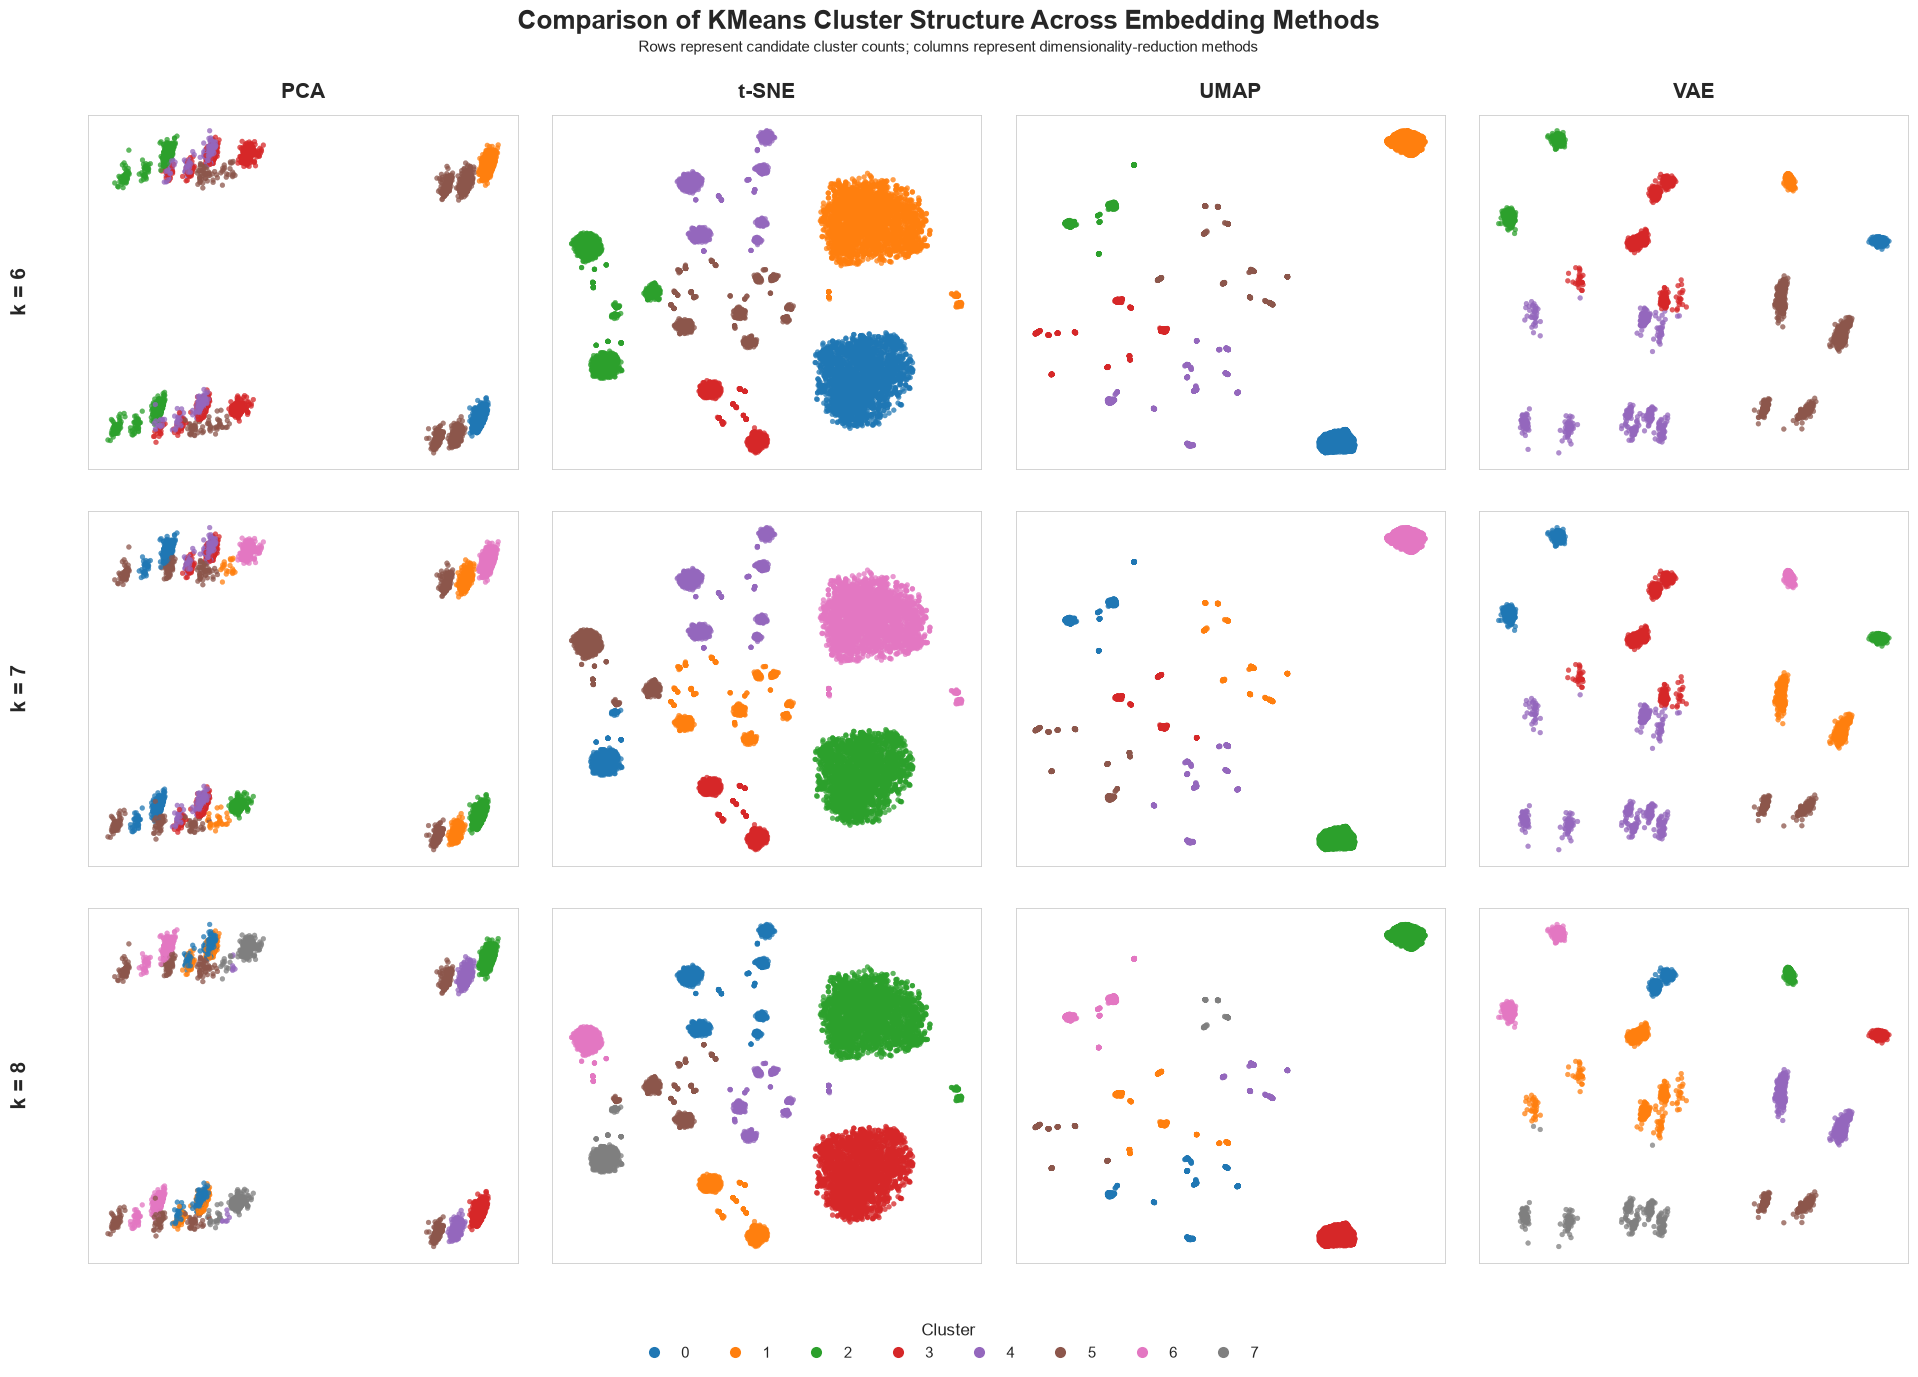

In [44]:
# Select KMeans solutions and embedding methods
k_values_to_plot = [6, 7, 8]
methods = ["PCA", "t-SNE", "UMAP", "VAE"]

# Use two-dimensional coordinates for all visualizations
plot_embeddings = {
    "PCA": pca_embedding[:, :2],
    "t-SNE": tsne_embedding,
    "UMAP": umap_embedding,
    "VAE": vae_embedding
}

# Use consistent colors across all clustering solutions
max_k = max(k_values_to_plot)
palette = sns.color_palette("tab10", max_k)

# Create publication-style 3 x 4 comparison grid
fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(20, 14)
)

for row, k in enumerate(k_values_to_plot):

    for col, method in enumerate(methods):

        ax = axes[row, col]

        coordinates = plot_embeddings[method]
        labels = matched_kmeans_labels[(method, k)]

        sns.scatterplot(
            x=coordinates[:, 0],
            y=coordinates[:, 1],
            hue=labels,
            palette=palette[:k],
            s=12,
            alpha=0.75,
            edgecolor=None,
            legend=False,
            ax=ax
        )

        # Embedding method headings
        if row == 0:
            ax.set_title(
                method,
                fontsize=15,
                fontweight="bold",
                pad=12
            )

        # Remove ordinary axis labels for a cleaner comparison
        ax.set_xlabel("")
        ax.set_ylabel("")

        ax.set_xticks([])
        ax.set_yticks([])

        # Keep subtle panel borders
        for spine in ax.spines.values():
            spine.set_linewidth(0.6)

# Add row labels separately from the plots
for row, k in enumerate(k_values_to_plot):

    axes[row, 0].text(
        -0.16,
        0.5,
        f"k = {k}",
        transform=axes[row, 0].transAxes,
        rotation=90,
        fontsize=15,
        fontweight="bold",
        va="center",
        ha="center"
    )

# Create one common legend
legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markersize=8,
        markerfacecolor=palette[cluster],
        markeredgecolor="none",
        label=str(cluster)
    )
    for cluster in range(max_k)
]

fig.legend(
    handles=legend_handles,
    title="Cluster",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=max_k,
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

fig.suptitle(
    "Comparison of KMeans Cluster Structure Across Embedding Methods",
    fontsize=19,
    fontweight="bold",
    y=0.985
)

fig.text(
    0.5,
    0.955,
    "Rows represent candidate cluster counts; columns represent dimensionality-reduction methods",
    ha="center",
    fontsize=11
)

plt.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.91,
    bottom=0.09,
    wspace=0.08,
    hspace=0.12
)

plt.savefig(
    PLOTS_DIR / "08.kmeans_grid_k6_k7_k8_publication.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# PCA 3D Visualization

## Create PCA with `n_components = 3`

In [45]:
pca_3d = PCA(
    n_components=3,
    svd_solver="full"
)

pca_3d_embedding = pca_3d.fit_transform(X)

# Calculate variance explained by each component
pca_3d_variance = (
    pca_3d.explained_variance_ratio_
    * 100
)

total_3d_variance = (
    pca_3d.explained_variance_ratio_.sum()
    * 100
)

print("=" * 80)
print("PCA 3D REPRESENTATION")
print("=" * 80)

print(
    f"{'PC1 Explained Variance':<35}: "
    f"{pca_3d_variance[0]:.2f}%"
)

print(
    f"{'PC2 Explained Variance':<35}: "
    f"{pca_3d_variance[1]:.2f}%"
)

print(
    f"{'PC3 Explained Variance':<35}: "
    f"{pca_3d_variance[2]:.2f}%"
)

print(
    f"{'Total Explained Variance':<35}: "
    f"{total_3d_variance:.2f}%"
)

print("=" * 80)

PCA 3D REPRESENTATION
PC1 Explained Variance             : 17.40%
PC2 Explained Variance             : 16.05%
PC3 Explained Variance             : 13.23%
Total Explained Variance           : 46.68%


## Plain PCA 3D Embedding

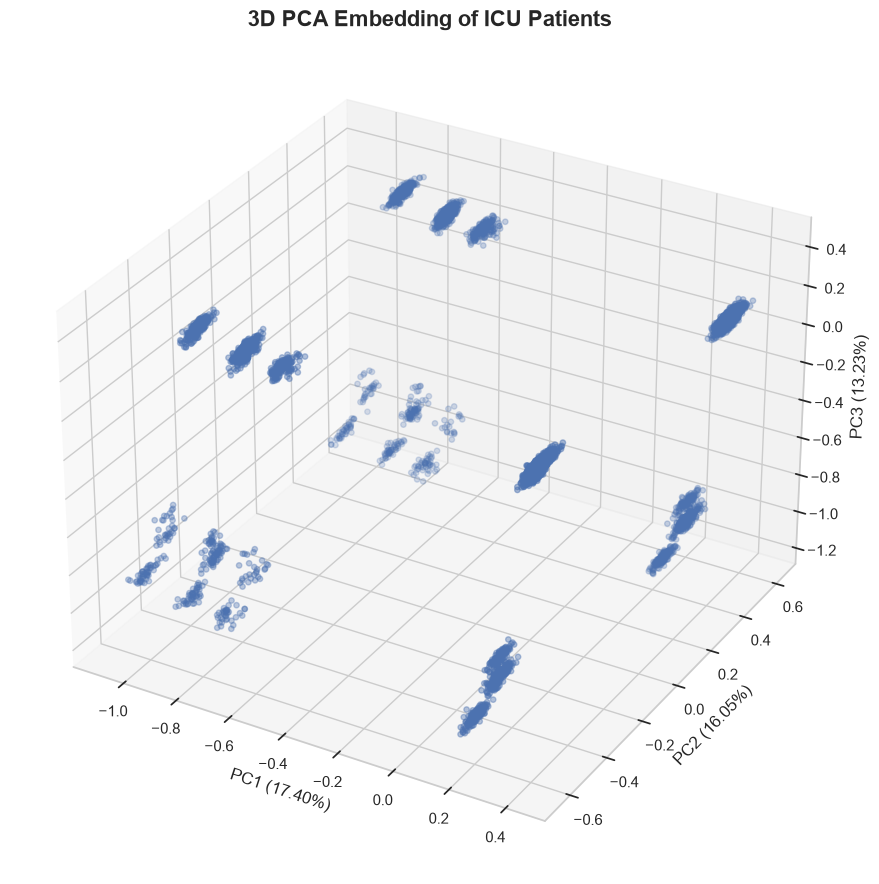

In [46]:
fig = plt.figure(
    figsize=(12, 9)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    pca_3d_embedding[:, 0],
    pca_3d_embedding[:, 1],
    pca_3d_embedding[:, 2],
    s=15,
    alpha=0.70
)

ax.set_xlabel(
    f"PC1 ({pca_3d_variance[0]:.2f}%)"
)

ax.set_ylabel(
    f"PC2 ({pca_3d_variance[1]:.2f}%)"
)

ax.set_zlabel(
    f"PC3 ({pca_3d_variance[2]:.2f}%)"
)

ax.set_title(
    "3D PCA Embedding of ICU Patients",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "11.pca_3d_embedding.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Run KMeans on the 3D PCA for `k = 6, 7, 8`

In [47]:
k_values_pca_3d = [6, 7, 8]

pca_3d_kmeans_models = {}
pca_3d_kmeans_labels = {}

for k in k_values_pca_3d:

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_SEED
    )

    labels = kmeans.fit_predict(
        pca_3d_embedding
    )

    pca_3d_kmeans_models[k] = kmeans
    pca_3d_kmeans_labels[k] = labels

## PCA 3D KMeans Visualization for `k = 6, 7, 8`

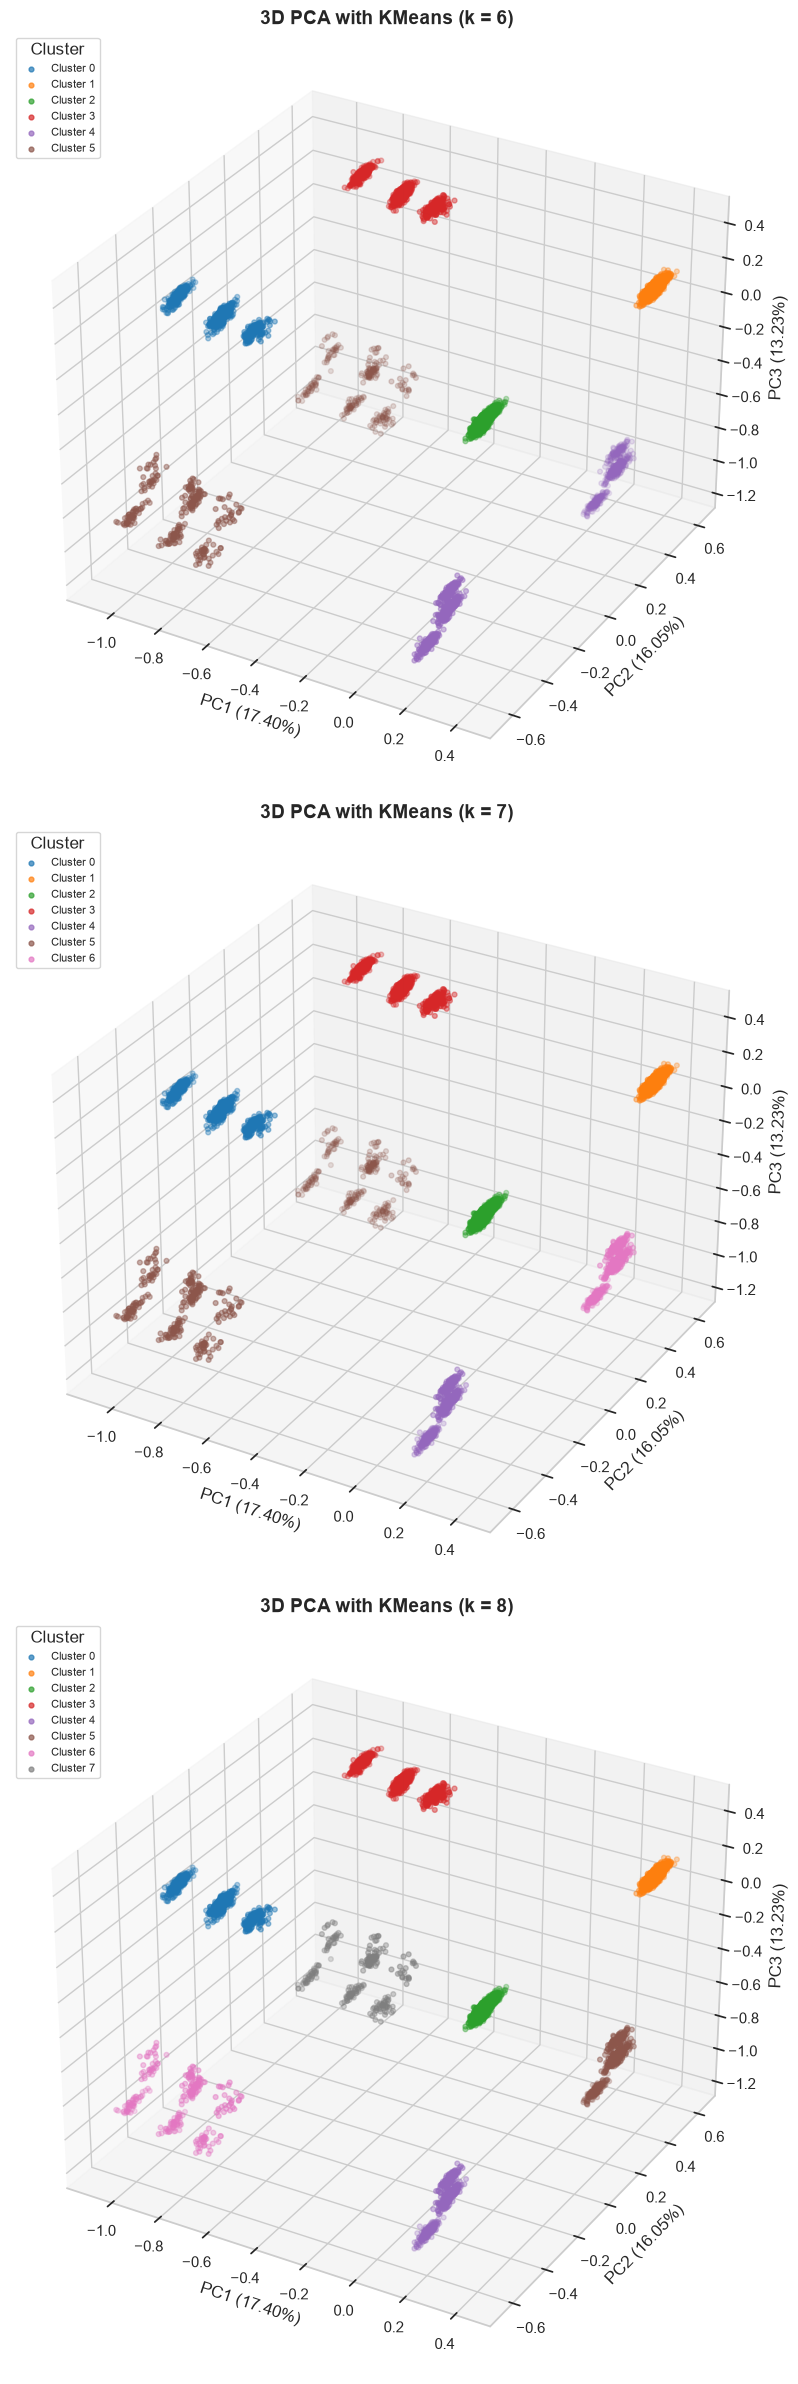

In [48]:
fig = plt.figure(
    figsize=(8, 24)
)

max_k = max(k_values_pca_3d)

palette = sns.color_palette(
    "tab10",
    max_k
)

for index, k in enumerate(
    k_values_pca_3d,
    start=1
):

    ax = fig.add_subplot(
        3,
        1,
        index,
        projection="3d"
    )

    labels = pca_3d_kmeans_labels[k]

    for cluster in range(k):

        cluster_mask = (
            labels == cluster
        )

        ax.scatter(
            pca_3d_embedding[
                cluster_mask,
                0
            ],
            pca_3d_embedding[
                cluster_mask,
                1
            ],
            pca_3d_embedding[
                cluster_mask,
                2
            ],
            s=12,
            alpha=0.70,
            color=palette[cluster],
            label=f"Cluster {cluster}"
        )

    ax.set_title(
        f"3D PCA with KMeans (k = {k})",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        f"PC1 ({pca_3d_variance[0]:.2f}%)"
    )

    ax.set_ylabel(
        f"PC2 ({pca_3d_variance[1]:.2f}%)"
    )

    ax.set_zlabel(
        f"PC3 ({pca_3d_variance[2]:.2f}%)"
    )

    ax.legend(
        title="Cluster",
        fontsize=8,
        loc="upper left"
    )

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "12.pca_3d_kmeans_k6_k7_k8.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
# Calculate feature loadings for PC1 and PC2
pca_loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=feature_names,
    columns=["PC1", "PC2"]
)

# Select the five strongest features for each component
top_pc1 = (
    pca_loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .head(5)
)

top_pc2 = (
    pca_loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
    .head(5)
)

pca_feature_influence = pd.DataFrame({
    "PC1 Feature": top_pc1.index,
    "PC1 Loading": pca_loadings.loc[top_pc1.index, "PC1"].values,
    "PC2 Feature": top_pc2.index,
    "PC2 Loading": pca_loadings.loc[top_pc2.index, "PC2"].values
})

display(
    pca_feature_influence
    .style
    .format({
        "PC1 Loading": "{:.3f}",
        "PC2 Loading": "{:.3f}"
    })
    .hide(axis="index")
)

PC1 Feature,PC1 Loading,PC2 Feature,PC2 Loading
unittype_Med-Surg ICU,0.878,gender,0.991
unittype_MICU,-0.361,ethnicity_Caucasian,0.054
unittype_Cardiac ICU,-0.196,Hgb_min,0.043
unittype_CCU-CTICU,-0.191,Hgb_mean,0.042
ethnicity_Caucasian,0.084,Hgb_max,0.041


**Observation :**

The large separation in the PCA representation is primarily driven by categorical patient characteristics. PC1 is strongly influenced by ICU type, particularly the `Med-Surg ICU` indicator, while PC2 is dominated by `gender`. Because these variables are encoded as discrete categories, PCA produces distinct patient groups with visible gaps between them. Laboratory features have much smaller loadings and contribute relatively little to these major separations.